# Label-Aligned Twitter RoBERTa with Stable Logit Pooling

This revision corrects two remaining weaknesses found from the latest diagnostics:

1. Arithmetic averaging of seed probabilities can dilute confident agreement and over-weight one uncertain seed. The final model now uses **mean log-odds (logit pooling)** as the prespecified multi-seed aggregation rule.
2. A coarse 0.005 threshold grid can miss narrow decision intervals. Validation diagnostics now evaluate exact probability-change intervals using midpoint candidates.

The primary decision rule is prespecified as logit-pooled seed probabilities with a 0.50 cutoff. A validation-selected challenger may replace it only when it gains at least three correct validation examples. The test set remains excluded from runtime selection.

The standardized metrics, prediction, error-analysis, interpretability, training-log, and model-artifact filenames remain compatible with the previous notebooks. Legacy columns remain first, with additional component-probability and provenance columns appended.


In [1]:
# ============================================================
# 1. Imports and environment
# ============================================================

import os
import gc
import re
import json
import math
import time
import html
import copy
import shutil
import hashlib
import random
import platform
import warnings
import unicodedata
import datetime as dt
from pathlib import Path
from itertools import product
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 140)

print("Python:", platform.python_version())
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
CUDA available: True
CUDA device: Tesla T4


In [2]:
# ============================================================
# 2. Central configuration
# ============================================================

CONFIG = {
    "project_name": "extremism_text_classification",
    "technique_name": "TWITTER-ROBERTA_LOGIT-POOL-STABLE",
    "model_family": "logit_pooled_multi_seed_hate_aligned_transformer",
    "feature_family": "contextual_transformer_logit_probability_pooling",
    "dataset_version": "extremism_dataset_clean_v1",
    "split_version": "split_v1",
    "random_seed": 30,
    "final_seeds": [17, 30, 73],

    # Canonical files from the dataset/split notebook.
    "processed_dataset_path": None,
    "split_assignments_path": None,
    "dataset_manifest_path": None,

    # Optional original-text file. When supplied, it must contain row_id and one
    # of raw_text_candidates. The transformer should receive the least-altered text.
    "raw_dataset_path": None,
    "raw_text_candidates": [
        "text_raw", "raw_text", "original_text", "original_tweet",
        "tweet", "content", "text",
    ],
    "text_normalization_mode": "minimal_twitter",  # identity | minimal_twitter

    # Evidence from the prior runs shows that the positive labels are strongly
    # hate/toxicity aligned. Preserve the task-aligned checkpoint and its head.
    "candidate_checkpoints": [
        "cardiffnlp/twitter-roberta-base-hate-latest",
        # A general encoder can be reintroduced as a separately reported challenger,
        # but it is intentionally not the default after the observed regression.
        # "cardiffnlp/twitter-roberta-base-2022-154m",
    ],
    "checkpoint_head_policy": {
        "cardiffnlp/twitter-roberta-base-hate-latest": "pretrained",
        "cardiffnlp/twitter-roberta-base-2022-154m": "fresh",
        "microsoft/deberta-v3-base": "fresh",
        "vinai/bertweet-base": "fresh",
    },
    "default_head_policy": "fresh",  # pretrained | fresh

    "id_col": "row_id",
    "text_col": "text",
    "label_col": "label",
    "split_col": "split",
    "positive_label": 1,

    "output_root": "/kaggle/working/experiments",
    "overwrite_output_dir": True,

    # Eight validation-only screening runs. This restores the original class-weight ablation.
    "ablation_grid": {
        "learning_rate": [2e-5, 3e-5],
        "num_epochs": [2, 3],
        "batch_size": [8],
        "max_length": [192],
        "weight_decay": [0.01],
        "label_smoothing": [0.0],
        "class_weight": [None, "balanced"],
    },

    "transformer_training": {
        "gradient_accumulation_steps": 2,
        "warmup_ratio": 0.10,
        "max_grad_norm": 1.0,
        "drop_last": False,
        "num_workers": 2,
        "use_amp_if_cuda": True,
        "amp_dtype": "auto",  # auto | bfloat16 | float16
        "force_fp32_master_weights": True,
        "early_stopping_patience_epochs": 1,
        # Align epoch selection with the actual objective rather than PR-AUC alone.
        "metric_for_best_epoch": "positive_f1",
        "save_all_seed_models": False,
    },

    "threshold_selection": {
        "metric": "accuracy",
        "threshold_grid": [round(x, 3) for x in np.linspace(0.05, 0.95, 181)],
        "candidate_mode": "exact_midpoints_plus_configured",
        # Select the exact best raw-probability validation threshold. Calibration is intentionally
        # disabled because fold-specific OOF calibration and full-fit test calibration created
        # incompatible probability scales in the previous notebook.
        "near_optimal_tolerance_correct_examples": 0,
        "bootstrap_repeats": 0,
    },

    "seed_aggregation": {
        "calibrate_probabilities": False,
        "calibration_folds": 5,
        "calibration_C": 1_000.0,
        "candidate_strategies": [
            "raw_logit_mean",
            "raw_mean",
            "best_raw_single_seed",
        ],
        # Stable primary rule. Challengers are validation-only and must improve
        # by a material number of examples before replacing this operating point.
        "prespecified_primary_strategy": "raw_logit_mean",
        "prespecified_primary_threshold": 0.50,
        "minimum_gain_correct_examples_over_primary": 3,
    },

    # Retained for comparability and diagnostics, but it cannot dominate the model.
    "char_tfidf": {
        "enabled": True,
        "analyzer": "char_wb",
        "ngram_range": (3, 5),
        "min_df": 2,
        "max_df": 1.0,
        "max_features": 200_000,
        "sublinear_tf": True,
        "lowercase": True,
        "C_values": [0.5, 1.0, 2.0, 4.0],
        "max_iter": 4000,
    },

    "ensemble": {
        "enabled": False,
        "blend_method": "probability_blend",
        # Character model weight is capped at 15%; transformer-only remains a candidate.
        "transformer_weight_grid": [1.00, 0.95, 0.90, 0.85],
        "probability_clip": 1e-6,
        # A weaker auxiliary model must earn entry rather than winning on a fragile tie.
        "minimum_validation_gain_correct_examples": 2,
        "maximum_positive_recall_drop": 0.01,
    },

    "explainability": {
        "top_n_global": 40,
        "top_n_local_tokens": 15,
        "local_examples_per_bucket": 8,
        "max_global_attribution_examples": 150,
        "max_text_chars_for_display": 400,
    },

    "error_analysis": {
        "examples_per_bucket": 30,
        "near_threshold_margin": 0.05,
        "high_confidence_positive": 0.90,
        "high_confidence_negative": 0.10,
        "include_text_preview": True,
        "text_preview_chars": 500,
    },
}

TECHNIQUE_NAME = CONFIG["technique_name"]
RUN_ID = f"{TECHNIQUE_NAME}_{dt.datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"
OUTPUT_DIR = Path(CONFIG["output_root"]) / TECHNIQUE_NAME

if CONFIG["overwrite_output_dir"] and OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

for subdir in [
    OUTPUT_DIR,
    OUTPUT_DIR / "ablation",
    OUTPUT_DIR / "auxiliary",
    OUTPUT_DIR / "model_artifacts",
    OUTPUT_DIR / "plots",
    OUTPUT_DIR / "interpretability",
    OUTPUT_DIR / "error_analysis",
    OUTPUT_DIR / "training_logs",
    OUTPUT_DIR / "data_quality",
]:
    subdir.mkdir(parents=True, exist_ok=True)

print("Run ID:", RUN_ID)
print("Output directory:", OUTPUT_DIR)
print(json.dumps(CONFIG, indent=2, default=str))


Run ID: TWITTER-ROBERTA_LOGIT-POOL-STABLE_20260808_191829
Output directory: /kaggle/working/experiments/TWITTER-ROBERTA_LOGIT-POOL-STABLE
{
  "project_name": "extremism_text_classification",
  "technique_name": "TWITTER-ROBERTA_LOGIT-POOL-STABLE",
  "model_family": "logit_pooled_multi_seed_hate_aligned_transformer",
  "feature_family": "contextual_transformer_logit_probability_pooling",
  "dataset_version": "extremism_dataset_clean_v1",
  "split_version": "split_v1",
  "random_seed": 30,
  "final_seeds": [
    17,
    30,
    73
  ],
  "processed_dataset_path": null,
  "split_assignments_path": null,
  "dataset_manifest_path": null,
  "raw_dataset_path": null,
  "raw_text_candidates": [
    "text_raw",
    "raw_text",
    "original_text",
    "original_tweet",
    "tweet",
    "content",
    "text"
  ],
  "text_normalization_mode": "minimal_twitter",
  "candidate_checkpoints": [
    "cardiffnlp/twitter-roberta-base-hate-latest"
  ],
  "checkpoint_head_policy": {
    "cardiffnlp/twitter

In [3]:
# ============================================================
# 3. Reproducibility, serialization, and file helpers
# ============================================================

def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # benchmark=True is faster; all seeds and selected configurations are still recorded.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return None if math.isnan(float(obj)) else float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if torch.is_tensor(obj):
        return obj.detach().cpu().tolist()
    try:
        if pd.isna(obj) and not isinstance(obj, (list, tuple, dict, np.ndarray)):
            return None
    except Exception:
        pass
    return obj


def save_json(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(make_json_safe(obj), f, indent=2, ensure_ascii=False)


def sha256_file(path: Path, n_chars: int = 16) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()[:n_chars]


def sha256_text(text: str, n_chars: int = 16) -> str:
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()[:n_chars]


def find_file_by_name(file_name: str, search_roots=None) -> Path:
    if search_roots is None:
        search_roots = [Path("/kaggle/input"), Path("/kaggle/working"), Path(".")]
    matches = []
    for root in search_roots:
        if root.exists():
            matches.extend(root.rglob(file_name))
    matches = sorted(set(matches), key=lambda p: (len(str(p)), str(p)))
    if not matches:
        raise FileNotFoundError(
            f"Could not find {file_name}. Set its exact path in CONFIG or attach it to the notebook."
        )
    if len(matches) > 1:
        print(f"Multiple matches found for {file_name}; using the shortest path:")
        for match in matches[:10]:
            print(" -", match)
    return matches[0]


def build_param_grid(grid: dict):
    keys = list(grid.keys())
    values = [grid[k] for k in keys]
    return [dict(zip(keys, combination)) for combination in product(*values)]


def sanitize_name(value: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(value)).strip("_")


set_global_seed(CONFIG["random_seed"])
save_json(CONFIG, OUTPUT_DIR / "config.json")
print("Seed set to", CONFIG["random_seed"])

Seed set to 30


In [4]:
# ============================================================
# 4. Load canonical dataset, split assignments, manifest, and optional raw text
# ============================================================

processed_dataset_path = (
    Path(CONFIG["processed_dataset_path"])
    if CONFIG["processed_dataset_path"] is not None
    else find_file_by_name("processed_dataset.csv")
)
split_assignments_path = (
    Path(CONFIG["split_assignments_path"])
    if CONFIG["split_assignments_path"] is not None
    else find_file_by_name("split_assignments.csv")
)
dataset_manifest_path = (
    Path(CONFIG["dataset_manifest_path"])
    if CONFIG["dataset_manifest_path"] is not None
    else find_file_by_name("dataset_manifest.json")
)

processed_df = pd.read_csv(processed_dataset_path)
splits = pd.read_csv(split_assignments_path)
with open(dataset_manifest_path, "r", encoding="utf-8") as f:
    dataset_manifest = json.load(f)

raw_df = None
raw_dataset_path = None
if CONFIG["raw_dataset_path"] is not None:
    raw_dataset_path = Path(CONFIG["raw_dataset_path"])
    raw_df = pd.read_csv(raw_dataset_path)

print("Processed dataset path:", processed_dataset_path)
print("Split assignments path:", split_assignments_path)
print("Dataset manifest path:", dataset_manifest_path)
print("Optional raw dataset path:", raw_dataset_path)
print("Processed dataset shape:", processed_df.shape)
print("Split assignment shape:", splits.shape)

display(processed_df.head())
display(splits.head())

Processed dataset path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/processed_dataset.csv
Split assignments path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/split_assignments.csv
Dataset manifest path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/dataset_manifest.json
Optional raw dataset path: None
Processed dataset shape: (2999, 8)
Split assignment shape: (2999, 4)


,row_id,original_index,text,label,raw_label,text_hash,char_len,word_len
0,ex_000000,0,sixth forms should burn to the ground,1,EXTREMIST,e0cc81a4d5f0f2b3,37,7
1,ex_000001,1,whatever should burn benders to the ground,1,EXTREMIST,906f97390ef91f64,42,7
2,ex_000002,2,factories should burn to the ground,1,EXTREMIST,50fe44bc8cf60d1c,35,6
3,ex_000003,3,halal factories should burn to the ground,1,EXTREMIST,4bedb3fea5ed5fbe,41,7
4,ex_000004,4,nhs should burn to the ground,1,EXTREMIST,f1a8b2543327a925,29,6


,row_id,label,text_hash,split
0,ex_000000,1,e0cc81a4d5f0f2b3,test
1,ex_000001,1,906f97390ef91f64,train
2,ex_000002,1,50fe44bc8cf60d1c,validation
3,ex_000003,1,4bedb3fea5ed5fbe,validation
4,ex_000004,1,f1a8b2543327a925,validation


In [5]:
# ============================================================
# 5. Validate schema, select the least-processed text, and apply canonical splits
# ============================================================

id_col = CONFIG["id_col"]
configured_text_col = CONFIG["text_col"]
label_col = CONFIG["label_col"]
split_col = CONFIG["split_col"]
MODEL_TEXT_COL = "__model_input_text"
SOURCE_TEXT_COL = "__source_text"

required_processed_cols = {id_col, label_col}
required_split_cols = {id_col, split_col}
missing_processed = required_processed_cols - set(processed_df.columns)
missing_splits = required_split_cols - set(splits.columns)
if missing_processed:
    raise ValueError(f"Processed dataset is missing required columns: {missing_processed}")
if missing_splits:
    raise ValueError(f"Split assignment file is missing required columns: {missing_splits}")
if processed_df[id_col].duplicated().any():
    raise ValueError("processed_dataset.csv contains duplicate row_id values.")
if splits[id_col].duplicated().any():
    raise ValueError("split_assignments.csv contains duplicate row_id values.")

working_df = processed_df.copy()
text_source_table = raw_df if raw_df is not None else working_df
text_source_name = "raw_dataset" if raw_df is not None else "processed_dataset"

if raw_df is not None:
    if id_col not in raw_df.columns:
        raise ValueError(f"Raw dataset must contain {id_col!r}.")
    if raw_df[id_col].duplicated().any():
        raise ValueError("Raw dataset contains duplicate row_id values.")

available_text_candidates = [
    column for column in CONFIG["raw_text_candidates"]
    if column in text_source_table.columns
]
if not available_text_candidates:
    raise ValueError(
        "No usable text column was found. Available columns are: "
        f"{sorted(text_source_table.columns.tolist())}"
    )
selected_source_text_col = available_text_candidates[0]

if raw_df is not None:
    raw_text_subset = raw_df[[id_col, selected_source_text_col]].rename(
        columns={selected_source_text_col: SOURCE_TEXT_COL}
    )
    working_df = working_df.merge(raw_text_subset, on=id_col, how="left", validate="one_to_one")
    if working_df[SOURCE_TEXT_COL].isna().any():
        missing_ids = working_df.loc[working_df[SOURCE_TEXT_COL].isna(), id_col].head().tolist()
        raise ValueError(f"Raw text is missing for some row_ids. Examples: {missing_ids}")
else:
    working_df[SOURCE_TEXT_COL] = working_df[selected_source_text_col]

URL_RE = re.compile(r"(?i)\b(?:https?://|www\.)\S+|\bhttp\S*")
USER_RE = re.compile(r"(?<!\w)@[A-Za-z0-9_]+")
WHITESPACE_RE = re.compile(r"\s+")


def normalize_model_text(text: str, mode: str) -> str:
    text = "" if pd.isna(text) else str(text)
    if mode == "identity":
        return text
    if mode != "minimal_twitter":
        raise ValueError(f"Unsupported text_normalization_mode: {mode}")
    # These operations preserve semantics while matching common Twitter-pretraining placeholders.
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)
    text = USER_RE.sub("@user", text)
    text = URL_RE.sub("http", text)
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text


working_df[SOURCE_TEXT_COL] = working_df[SOURCE_TEXT_COL].fillna("").astype(str)
working_df[MODEL_TEXT_COL] = working_df[SOURCE_TEXT_COL].map(
    lambda value: normalize_model_text(value, CONFIG["text_normalization_mode"])
)
working_df[label_col] = working_df[label_col].astype(int)

merged = working_df.merge(
    splits[[id_col, split_col]], on=id_col, how="left", validate="one_to_one"
)
if merged[split_col].isna().any():
    missing_ids = merged.loc[merged[split_col].isna(), id_col].head().tolist()
    raise ValueError(f"Some rows are missing split assignments. Examples: {missing_ids}")

allowed_splits = {"train", "validation", "test"}
observed_splits = set(merged[split_col].unique())
if not observed_splits.issubset(allowed_splits):
    raise ValueError(f"Unexpected split labels: {observed_splits - allowed_splits}")
if not set(merged[label_col].unique()).issubset({0, 1}):
    raise ValueError("This notebook expects binary labels encoded as 0 and 1.")

train_df = merged[merged[split_col] == "train"].reset_index(drop=True)
val_df = merged[merged[split_col] == "validation"].reset_index(drop=True)
test_df = merged[merged[split_col] == "test"].reset_index(drop=True)
if min(len(train_df), len(val_df), len(test_df)) == 0:
    raise ValueError("Train, validation, and test splits must all be non-empty.")

text_source_audit = {
    "text_source_table": text_source_name,
    "selected_source_text_column": selected_source_text_col,
    "normalization_mode": CONFIG["text_normalization_mode"],
    "raw_dataset_supplied": raw_df is not None,
    "warning": None,
}
if raw_df is None and selected_source_text_col == configured_text_col:
    text_source_audit["warning"] = (
        "The notebook is using the processed text column because no separate raw-text file/column was supplied. "
        "If upstream text repair expanded acronyms or changed wording, regenerate the dataset with raw text or set raw_dataset_path."
    )
    print("WARNING:", text_source_audit["warning"])

save_json(text_source_audit, OUTPUT_DIR / "data_quality" / "text_source_audit.json")

print("Selected source text:", f"{text_source_name}.{selected_source_text_col}")
print("Split sizes:", {"train": len(train_df), "validation": len(val_df), "test": len(test_df)})

split_audit = merged.groupby([split_col, label_col]).size().reset_index(name="count")
split_audit["rate_within_split"] = split_audit.groupby(split_col)["count"].transform(lambda s: s / s.sum())
split_audit.to_csv(OUTPUT_DIR / "split_label_distribution_used.csv", index=False)
display(split_audit)

Selected source text: processed_dataset.text
Split sizes: {'train': 2099, 'validation': 450, 'test': 450}


,split,label,count,rate_within_split
0,test,0,280,0.622222
1,test,1,170,0.377778
2,train,0,1309,0.623630
3,train,1,790,0.376370
4,validation,0,281,0.624444
5,validation,1,169,0.375556


In [6]:
# ============================================================
# 6. Data-quality and leakage audit
# ============================================================

quality_df = merged[[id_col, split_col, label_col, SOURCE_TEXT_COL, MODEL_TEXT_COL]].copy()
quality_df["model_text_hash"] = quality_df[MODEL_TEXT_COL].map(sha256_text)
quality_df["source_text_length"] = quality_df[SOURCE_TEXT_COL].str.len()
quality_df["model_text_length"] = quality_df[MODEL_TEXT_COL].str.len()

empty_model_text = quality_df[quality_df["model_text_length"] == 0].copy()
duplicate_groups = (
    quality_df.groupby("model_text_hash", as_index=False)
    .agg(
        row_count=(id_col, "size"),
        split_count=(split_col, "nunique"),
        label_count=(label_col, "nunique"),
        splits=(split_col, lambda s: "|".join(sorted(set(map(str, s))))),
        labels=(label_col, lambda s: "|".join(sorted(set(map(str, s))))),
    )
)
cross_split_duplicates = duplicate_groups[
    (duplicate_groups["row_count"] > 1) & (duplicate_groups["split_count"] > 1)
].copy()
conflicting_label_duplicates = duplicate_groups[
    (duplicate_groups["row_count"] > 1) & (duplicate_groups["label_count"] > 1)
].copy()

cross_split_duplicates.to_csv(
    OUTPUT_DIR / "data_quality" / "cross_split_duplicate_text_groups.csv", index=False
)
conflicting_label_duplicates.to_csv(
    OUTPUT_DIR / "data_quality" / "conflicting_label_duplicate_text_groups.csv", index=False
)
empty_model_text.to_csv(OUTPUT_DIR / "data_quality" / "empty_model_text_rows.csv", index=False)

quality_summary = {
    "empty_model_text_rows": len(empty_model_text),
    "cross_split_duplicate_text_groups": len(cross_split_duplicates),
    "conflicting_label_duplicate_text_groups": len(conflicting_label_duplicates),
    "recommendation": (
        "For a final publishable benchmark, group exact/near duplicates into one split and manually resolve conflicting labels."
    ),
}
save_json(quality_summary, OUTPUT_DIR / "data_quality" / "data_quality_summary.json")
print(json.dumps(quality_summary, indent=2))

{
  "empty_model_text_rows": 0,
  "cross_split_duplicate_text_groups": 0,
  "conflicting_label_duplicate_text_groups": 0,
  "recommendation": "For a final publishable benchmark, group exact/near duplicates into one split and manually resolve conflicting labels."
}


In [7]:
# ============================================================
# 7. Metrics, threshold selection, blending, and prediction utilities
# ============================================================

def safe_roc_auc(y_true, y_prob):
    try:
        return np.nan if len(np.unique(y_true)) < 2 else roc_auc_score(y_true, y_prob)
    except Exception:
        return np.nan


def safe_pr_auc(y_true, y_prob):
    try:
        return np.nan if len(np.unique(y_true)) < 2 else average_precision_score(y_true, y_prob)
    except Exception:
        return np.nan


def compute_binary_metrics(y_true, y_prob, threshold, positive_label=1):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= float(threshold)).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "support": int(len(y_true)),
        "positive_support": int((y_true == positive_label).sum()),
        "negative_support": int((y_true != positive_label).sum()),
        "positive_rate": float((y_true == positive_label).mean()),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "precision_weighted": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "recall_weighted": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "positive_precision": float(precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "positive_recall": float(recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "positive_f1": float(f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "roc_auc": float(safe_roc_auc(y_true, y_prob)),
        "pr_auc": float(safe_pr_auc(y_true, y_prob)),
        "brier_score": float(brier_score_loss(y_true, y_prob)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) else np.nan,
        "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) else np.nan,
    }


def build_threshold_candidates(y_prob, configured_thresholds=None):
    """Return all decision-change intervals plus configured reference cutoffs.

    For predictions defined by p >= threshold, accuracy can change only when the
    threshold crosses a predicted probability. Midpoints between adjacent unique
    probabilities represent every distinct prediction set without relying on a
    coarse grid. Configured thresholds and 0.50 are retained for comparability.
    """
    probability = np.asarray(y_prob, dtype=float)
    probability = probability[np.isfinite(probability)]
    if probability.size == 0:
        raise ValueError("No finite probabilities were supplied for threshold selection.")

    unique_probability = np.unique(np.clip(probability, 0.0, 1.0))
    if unique_probability.size > 1:
        midpoint_candidates = (
            unique_probability[:-1] + unique_probability[1:]
        ) / 2.0
    else:
        midpoint_candidates = unique_probability.copy()

    configured = np.asarray(
        list(configured_thresholds or []) + [0.50], dtype=float
    )
    candidates = np.unique(np.concatenate([
        midpoint_candidates,
        configured,
        np.array([0.0, 1.0], dtype=float),
    ]))
    return candidates[(candidates >= 0.0) & (candidates <= 1.0)]


def select_threshold(y_true, y_prob, thresholds, metric="accuracy"):
    candidate_thresholds = build_threshold_candidates(y_prob, thresholds)
    rows = [
        compute_binary_metrics(y_true, y_prob, threshold, CONFIG["positive_label"])
        for threshold in candidate_thresholds
    ]
    threshold_df = pd.DataFrame(rows)
    threshold_df["distance_to_0_50"] = (threshold_df["threshold"] - 0.50).abs()
    # Accuracy is primary. Macro/balanced metrics prevent a majority-class tie-break.
    threshold_df = threshold_df.sort_values(
        by=[metric, "balanced_accuracy", "f1_macro", "positive_f1", "distance_to_0_50"],
        ascending=[False, False, False, False, True],
    ).reset_index(drop=True)
    return float(threshold_df.iloc[0]["threshold"]), threshold_df


def probability_to_logit(probability, eps=1e-6):
    p = np.clip(np.asarray(probability, dtype=float), eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


def sigmoid(values):
    values = np.clip(np.asarray(values, dtype=float), -40, 40)
    return 1.0 / (1.0 + np.exp(-values))


def blend_probabilities(transformer_prob, char_prob, transformer_weight, method="logit_blend"):
    w = float(transformer_weight)
    if method == "probability_blend":
        return w * np.asarray(transformer_prob) + (1.0 - w) * np.asarray(char_prob)
    if method == "logit_blend":
        eps = CONFIG["ensemble"]["probability_clip"]
        mixed_logit = (
            w * probability_to_logit(transformer_prob, eps)
            + (1.0 - w) * probability_to_logit(char_prob, eps)
        )
        return sigmoid(mixed_logit)
    raise ValueError(f"Unsupported blend method: {method}")


def make_prediction_frame(source_df, final_prob, threshold, component_probabilities=None):
    out = source_df[[id_col, SOURCE_TEXT_COL, MODEL_TEXT_COL, label_col, split_col]].copy()
    out = out.rename(
        columns={
            id_col: "row_id",
            SOURCE_TEXT_COL: "text",
            MODEL_TEXT_COL: "model_input_text",
            label_col: "y_true",
        }
    )
    out["y_prob"] = np.asarray(final_prob, dtype=float)
    out["threshold"] = float(threshold)
    out["y_pred"] = (out["y_prob"] >= threshold).astype(int)
    out["correct"] = out["y_true"] == out["y_pred"]
    out["error_type"] = "correct"
    out.loc[(out["y_true"] == 0) & (out["y_pred"] == 1), "error_type"] = "false_positive"
    out.loc[(out["y_true"] == 1) & (out["y_pred"] == 0), "error_type"] = "false_negative"
    out["text_hash"] = out["text"].map(sha256_text)
    if component_probabilities:
        for name, values in component_probabilities.items():
            out[name] = np.asarray(values, dtype=float)

    legacy_prediction_columns = [
        "row_id", "text", "y_true", "split", "y_prob", "threshold",
        "y_pred", "correct", "error_type", "text_hash",
    ]
    extra_prediction_columns = [
        column for column in out.columns if column not in legacy_prediction_columns
    ]
    return out[legacy_prediction_columns + extra_prediction_columns]

def _fast_accuracy_by_threshold(y_true, y_prob, thresholds):
    y = np.asarray(y_true, dtype=int)[:, None]
    p = np.asarray(y_prob, dtype=float)[:, None]
    t = np.asarray(thresholds, dtype=float)[None, :]
    return ((p >= t).astype(int) == y).mean(axis=0)


def _stratified_bootstrap_indices(y_true, rng):
    y = np.asarray(y_true, dtype=int)
    sampled_parts = []
    for label in np.unique(y):
        label_indices = np.flatnonzero(y == label)
        sampled_parts.append(
            rng.choice(label_indices, size=len(label_indices), replace=True)
        )
    sampled = np.concatenate(sampled_parts)
    rng.shuffle(sampled)
    return sampled


def select_stable_threshold(
    y_true,
    y_prob,
    thresholds,
    metric="accuracy",
    tolerance_correct_examples=1,
    bootstrap_repeats=200,
    random_seed=30,
):
    """Select a validation threshold from a near-optimal, bootstrap-stable region.

    The ordinary threshold sweep remains fully saved for comparability. The final
    threshold is not required to be the single sharp maximum when neighboring
    thresholds differ by only one validation example.
    """
    base_threshold, threshold_df = select_threshold(
        y_true, y_prob, thresholds, metric=metric
    )
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    # Use exactly the candidate set evaluated by select_threshold, including
    # probability midpoints that represent every distinct decision interval.
    thresholds = np.sort(threshold_df["threshold"].astype(float).unique())

    best_metric = float(threshold_df[metric].max())
    tolerance = float(tolerance_correct_examples) / max(1, len(y_true))
    eligible = threshold_df[
        threshold_df[metric] >= best_metric - tolerance - 1e-12
    ].copy()

    rng = np.random.default_rng(int(random_seed))
    bootstrap_choices = []
    repeats = max(0, int(bootstrap_repeats))
    for _ in range(repeats):
        sample_idx = _stratified_bootstrap_indices(y_true, rng)
        sampled_accuracy = _fast_accuracy_by_threshold(
            y_true[sample_idx], y_prob[sample_idx], thresholds
        )
        best_indices = np.flatnonzero(
            sampled_accuracy >= sampled_accuracy.max() - 1e-12
        )
        bootstrap_choices.append(float(np.median(thresholds[best_indices])))

    bootstrap_anchor = (
        float(np.median(bootstrap_choices))
        if bootstrap_choices else float(base_threshold)
    )
    eligible["distance_to_bootstrap_anchor"] = (
        eligible["threshold"] - bootstrap_anchor
    ).abs()
    eligible["distance_to_0_50"] = (eligible["threshold"] - 0.50).abs()
    eligible = eligible.sort_values(
        [
            metric,
            "balanced_accuracy",
            "positive_f1",
            "f1_macro",
            "distance_to_bootstrap_anchor",
            "brier_score",
            "distance_to_0_50",
        ],
        ascending=[False, False, False, False, True, True, True],
    ).reset_index(drop=True)

    selected_threshold = float(eligible.iloc[0]["threshold"])
    threshold_df["selected_by_stable_rule"] = (
        threshold_df["threshold"].astype(float) == selected_threshold
    )
    threshold_df["bootstrap_anchor_threshold"] = bootstrap_anchor
    threshold_df["near_optimal_metric_floor"] = best_metric - tolerance

    stability = {
        "base_best_threshold": float(base_threshold),
        "selected_threshold": selected_threshold,
        "bootstrap_anchor_threshold": bootstrap_anchor,
        "best_validation_metric": best_metric,
        "near_optimal_tolerance": tolerance,
        "eligible_threshold_count": int(len(eligible)),
        "bootstrap_repeats": repeats,
    }
    return selected_threshold, threshold_df, stability


def fit_platt_calibrator(y_true, y_prob, C=1000.0):
    x = probability_to_logit(y_prob).reshape(-1, 1)
    calibrator = LogisticRegression(
        C=float(C),
        solver="lbfgs",
        max_iter=2000,
        random_state=CONFIG["random_seed"],
    )
    calibrator.fit(x, np.asarray(y_true, dtype=int))
    return calibrator


def apply_platt_calibrator(calibrator, y_prob):
    x = probability_to_logit(y_prob).reshape(-1, 1)
    return calibrator.predict_proba(x)[:, 1]


def cross_fitted_platt_calibration(
    y_val,
    val_prob,
    test_prob,
    n_splits=5,
    random_seed=30,
    C=1000.0,
):
    """Create out-of-fold calibrated validation probabilities and a full-val test mapping."""
    y_val = np.asarray(y_val, dtype=int)
    val_prob = np.asarray(val_prob, dtype=float)
    test_prob = np.asarray(test_prob, dtype=float)

    minimum_class_count = int(pd.Series(y_val).value_counts().min())
    folds = max(2, min(int(n_splits), minimum_class_count))
    splitter = StratifiedKFold(
        n_splits=folds,
        shuffle=True,
        random_state=int(random_seed),
    )
    oof_calibrated = np.zeros_like(val_prob, dtype=float)

    for fit_idx, holdout_idx in splitter.split(val_prob, y_val):
        calibrator = fit_platt_calibrator(
            y_val[fit_idx], val_prob[fit_idx], C=C
        )
        oof_calibrated[holdout_idx] = apply_platt_calibrator(
            calibrator, val_prob[holdout_idx]
        )

    final_calibrator = fit_platt_calibrator(y_val, val_prob, C=C)
    calibrated_test = apply_platt_calibrator(final_calibrator, test_prob)
    return oof_calibrated, calibrated_test, final_calibrator


In [8]:
# ============================================================
# 8. Transformer dataset and deterministic dataloaders
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts = [str(value) for value in texts]
        self.labels = None if labels is None else np.asarray(labels).astype(int).tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        item = {"text": self.texts[index]}
        if self.labels is not None:
            item["label"] = int(self.labels[index])
        return item


def make_collate_fn(tokenizer, max_length):
    def collate_fn(batch):
        encoded = tokenizer(
            [item["text"] for item in batch],
            truncation=True,
            padding=True,
            max_length=int(max_length),
            return_tensors="pt",
        )
        if "label" in batch[0]:
            encoded["labels"] = torch.tensor([item["label"] for item in batch], dtype=torch.long)
        return encoded
    return collate_fn


def make_dataloader(df_part, tokenizer, batch_size, max_length, shuffle=False, seed=30):
    dataset = TextClassificationDataset(
        texts=df_part[MODEL_TEXT_COL].tolist(),
        labels=df_part[label_col].tolist(),
    )
    generator = torch.Generator()
    generator.manual_seed(int(seed))
    return DataLoader(
        dataset,
        batch_size=int(batch_size),
        shuffle=bool(shuffle),
        collate_fn=make_collate_fn(tokenizer, max_length),
        num_workers=int(CONFIG["transformer_training"]["num_workers"]),
        drop_last=bool(CONFIG["transformer_training"]["drop_last"]),
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
        generator=generator,
    )

Using device: cuda


In [9]:
# ============================================================
# 9. Model loading with checkpoint-specific classifier-head policy
# ============================================================

def reinitialize_classification_head(model):
    head_name = None
    head = None
    for candidate in ["classifier", "score", "classification_head"]:
        if hasattr(model, candidate):
            head_name = candidate
            head = getattr(model, candidate)
            break
    if head is None:
        raise AttributeError(
            "Could not identify the classification head. Add this architecture's head attribute to the helper."
        )

    if hasattr(model, "_init_weights"):
        head.apply(model._init_weights)
    else:
        for module in head.modules():
            if hasattr(module, "reset_parameters"):
                module.reset_parameters()
    return head_name


def floating_parameter_dtypes(model):
    counts = {}
    for parameter in model.parameters():
        if parameter.requires_grad and parameter.is_floating_point():
            name = str(parameter.dtype).replace("torch.", "")
            counts[name] = counts.get(name, 0) + 1
    return counts


def checkpoint_head_policy(model_name_or_path):
    exact = CONFIG.get("checkpoint_head_policy", {}).get(model_name_or_path)
    policy = exact or CONFIG.get("default_head_policy", "fresh")
    policy = str(policy).strip().lower()
    if policy not in {"pretrained", "fresh"}:
        raise ValueError(
            f"Head policy for {model_name_or_path!r} must be 'pretrained' or 'fresh', got {policy!r}."
        )
    return policy


def load_tokenizer_and_model(model_name_or_path, random_seed):
    set_global_seed(random_seed)
    tokenizer = AutoTokenizer.from_pretrained(model_name_or_path, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name_or_path,
        num_labels=2,
        id2label={0: "non_extremist", 1: "extremist"},
        label2id={"non_extremist": 0, "extremist": 1},
        ignore_mismatched_sizes=True,
    )

    if CONFIG["transformer_training"].get("force_fp32_master_weights", True):
        model = model.float()

    head_policy = checkpoint_head_policy(model_name_or_path)
    reset_head_name = None
    if head_policy == "fresh":
        reset_head_name = reinitialize_classification_head(model)

    dtype_counts = floating_parameter_dtypes(model)
    non_fp32 = {dtype: count for dtype, count in dtype_counts.items() if dtype != "float32"}
    if non_fp32:
        raise RuntimeError(
            "Trainable transformer parameters must be FP32 before optimizer creation. "
            f"Observed non-FP32 parameter dtypes: {non_fp32}"
        )

    print(
        f"Loaded {model_name_or_path} with classifier-head policy={head_policy}; "
        f"reinitialized_head={reset_head_name}"
    )
    return tokenizer, model, reset_head_name, head_policy


In [10]:
# ============================================================
# 10. Transformer training and inference
# ============================================================

def resolve_amp_runtime():
    """Resolve a safe AMP policy for the current accelerator."""
    requested = bool(CONFIG["transformer_training"].get("use_amp_if_cuda", True))
    if not requested or DEVICE.type != "cuda":
        return {
            "enabled": False,
            "dtype": torch.float32,
            "dtype_name": "float32",
            "use_grad_scaler": False,
        }

    preference = str(
        CONFIG["transformer_training"].get("amp_dtype", "auto")
    ).strip().lower()
    if preference not in {"auto", "bfloat16", "float16"}:
        raise ValueError("amp_dtype must be one of: auto, bfloat16, float16")

    bf16_supported = bool(
        hasattr(torch.cuda, "is_bf16_supported") and torch.cuda.is_bf16_supported()
    )
    if preference == "bfloat16" and not bf16_supported:
        warnings.warn(
            "BF16 AMP was requested but is not supported by this GPU; falling back to FP16 AMP."
        )
        preference = "float16"

    if preference == "bfloat16" or (preference == "auto" and bf16_supported):
        amp_dtype = torch.bfloat16
        use_grad_scaler = False  # BF16 normally does not need loss scaling.
    else:
        amp_dtype = torch.float16
        use_grad_scaler = True

    return {
        "enabled": True,
        "dtype": amp_dtype,
        "dtype_name": str(amp_dtype).replace("torch.", ""),
        "use_grad_scaler": use_grad_scaler,
    }


def amp_autocast_context(amp_runtime):
    if not amp_runtime["enabled"]:
        return nullcontext()
    return torch.autocast(
        device_type=DEVICE.type,
        dtype=amp_runtime["dtype"],
        enabled=True,
    )


def make_grad_scaler(enabled):
    """Support both current torch.amp and older torch.cuda.amp APIs."""
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def verify_fp32_optimizer_parameters(model):
    bad = []
    for name, parameter in model.named_parameters():
        if (
            parameter.requires_grad
            and parameter.is_floating_point()
            and parameter.dtype != torch.float32
        ):
            bad.append((name, str(parameter.dtype)))
    if bad:
        preview = bad[:10]
        raise RuntimeError(
            "Optimizer parameters must remain FP32 when using AMP. "
            f"Found {len(bad)} non-FP32 trainable parameters; first entries: {preview}"
        )


def resolve_class_weight_tensor(class_weight_spec, labels, num_labels=2):
    """Resolve a class-weight specification into a FP32 tensor on DEVICE.

    Supported values:
      - None: ordinary unweighted cross-entropy
      - "balanced": sklearn-style inverse-frequency weights
      - dict: e.g. {0: 0.8, 1: 1.2}
      - list/tuple/ndarray: one positive finite weight per class
    """
    if class_weight_spec is None:
        return None, None

    y = np.asarray(labels, dtype=int)
    if y.ndim != 1 or len(y) == 0:
        raise ValueError("Training labels must be a non-empty one-dimensional array.")
    if y.min() < 0 or y.max() >= int(num_labels):
        raise ValueError(
            f"Training labels must be integers in [0, {int(num_labels) - 1}]. "
            f"Observed range: [{int(y.min())}, {int(y.max())}]"
        )

    if isinstance(class_weight_spec, str):
        if class_weight_spec.strip().lower() != "balanced":
            raise ValueError(
                "class_weight must be None, 'balanced', a dict, or a sequence of weights. "
                f"Received: {class_weight_spec!r}"
            )
        counts = np.bincount(y, minlength=int(num_labels)).astype(np.float64)
        if np.any(counts == 0):
            missing = np.flatnonzero(counts == 0).tolist()
            raise ValueError(
                f"Cannot compute balanced class weights because training classes {missing} have zero examples."
            )
        # Same formula used by sklearn.utils.class_weight.compute_class_weight('balanced').
        weights = len(y) / (float(num_labels) * counts)
    elif isinstance(class_weight_spec, dict):
        weights = np.asarray(
            [class_weight_spec.get(i, class_weight_spec.get(str(i), np.nan)) for i in range(int(num_labels))],
            dtype=np.float64,
        )
    else:
        weights = np.asarray(class_weight_spec, dtype=np.float64)

    if weights.shape != (int(num_labels),):
        raise ValueError(
            f"Expected exactly {int(num_labels)} class weights; received shape {weights.shape}."
        )
    if not np.all(np.isfinite(weights)) or np.any(weights <= 0):
        raise ValueError(f"Class weights must be finite and strictly positive. Received: {weights.tolist()}")

    weight_tensor = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
    return weight_tensor, [float(value) for value in weights]


def predict_transformer_proba(model, dataloader):
    model.eval()
    probabilities, labels = [], []
    amp_runtime = resolve_amp_runtime()
    with torch.inference_mode():
        for batch in dataloader:
            batch = {
                key: value.to(DEVICE, non_blocking=True)
                for key, value in batch.items()
            }
            y = batch.pop("labels", None)
            with amp_autocast_context(amp_runtime):
                outputs = model(**batch)
                batch_prob = torch.softmax(outputs.logits.float(), dim=-1)[:, 1]
            probabilities.extend(batch_prob.detach().cpu().numpy().tolist())
            if y is not None:
                labels.extend(y.detach().cpu().numpy().tolist())
    return np.asarray(probabilities, dtype=float), np.asarray(labels, dtype=int)


def train_transformer_config(config_params, run_label="config", random_seed=None):
    seed = CONFIG["random_seed"] if random_seed is None else int(random_seed)
    checkpoint = config_params["checkpoint"]

    # A previous failed CUDA run can retain references through a notebook traceback.
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    tokenizer, model, reset_head_name, head_policy = load_tokenizer_and_model(checkpoint, seed)
    model.to(device=DEVICE, dtype=torch.float32)
    verify_fp32_optimizer_parameters(model)

    train_loader = make_dataloader(
        train_df, tokenizer,
        batch_size=config_params["batch_size"],
        max_length=config_params["max_length"],
        shuffle=True,
        seed=seed,
    )
    val_loader = make_dataloader(
        val_df, tokenizer,
        batch_size=config_params["batch_size"],
        max_length=config_params["max_length"],
        shuffle=False,
        seed=seed,
    )

    class_weight_tensor, resolved_class_weights = resolve_class_weight_tensor(
        config_params.get("class_weight"),
        train_df[label_col].to_numpy(),
        num_labels=2,
    )
    criterion = nn.CrossEntropyLoss(
        weight=class_weight_tensor,
        label_smoothing=float(config_params.get("label_smoothing", 0.0)),
    )
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(config_params["learning_rate"]),
        weight_decay=float(config_params["weight_decay"]),
    )

    grad_accum = int(CONFIG["transformer_training"]["gradient_accumulation_steps"])
    if grad_accum < 1:
        raise ValueError("gradient_accumulation_steps must be at least 1")

    num_epochs = int(config_params["num_epochs"])
    total_update_steps = max(1, math.ceil(len(train_loader) / grad_accum) * num_epochs)
    warmup_steps = int(CONFIG["transformer_training"]["warmup_ratio"] * total_update_steps)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_update_steps,
    )

    amp_runtime = resolve_amp_runtime()
    scaler = make_grad_scaler(enabled=amp_runtime["use_grad_scaler"])
    print(
        f"{run_label} | device={DEVICE} | AMP={amp_runtime['enabled']} | "
        f"AMP dtype={amp_runtime['dtype_name']} | GradScaler={amp_runtime['use_grad_scaler']} | "
        f"class_weight={config_params.get('class_weight')} | resolved_weights={resolved_class_weights} | "
        f"trainable parameter dtypes={floating_parameter_dtypes(model)}"
    )

    monitor_name = CONFIG["transformer_training"]["metric_for_best_epoch"]
    best_metric = -np.inf
    best_monitor_key = None
    best_epoch = None
    best_state_dict = None
    best_val_prob = None
    best_val_metrics_at_050 = None
    best_val_metrics_at_optimized_threshold = None
    training_history = []
    patience = int(CONFIG["transformer_training"]["early_stopping_patience_epochs"])
    epochs_without_improvement = 0

    train_batches = len(train_loader)
    final_window_size = train_batches % grad_accum

    for epoch in range(1, num_epochs + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        total_unscaled_loss = 0.0

        for step, batch in enumerate(train_loader, start=1):
            batch = {
                key: value.to(DEVICE, non_blocking=True)
                for key, value in batch.items()
            }
            labels = batch.pop("labels")

            # Correctly normalize a final partial accumulation window instead of
            # underweighting it when len(train_loader) is not divisible by grad_accum.
            in_partial_final_window = (
                final_window_size > 0 and step > train_batches - final_window_size
            )
            accumulation_divisor = (
                final_window_size if in_partial_final_window else grad_accum
            )

            with amp_autocast_context(amp_runtime):
                outputs = model(**batch)
                unscaled_loss = criterion(outputs.logits.float(), labels)
                loss = unscaled_loss / accumulation_divisor

            if amp_runtime["use_grad_scaler"]:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            total_unscaled_loss += float(unscaled_loss.detach().cpu())

            should_update = step % grad_accum == 0 or step == train_batches
            if should_update:
                if amp_runtime["use_grad_scaler"]:
                    scaler.unscale_(optimizer)

                grad_norm = torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    float(CONFIG["transformer_training"]["max_grad_norm"]),
                )
                if not torch.isfinite(grad_norm):
                    optimizer.zero_grad(set_to_none=True)
                    raise FloatingPointError(
                        f"Non-finite gradient norm detected in {run_label}, epoch={epoch}, step={step}: "
                        f"{float(grad_norm.detach().cpu())}"
                    )

                if amp_runtime["use_grad_scaler"]:
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    optimizer.step()

                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

        val_prob, val_true = predict_transformer_proba(model, val_loader)
        val_metrics_050 = compute_binary_metrics(val_true, val_prob, 0.50, CONFIG["positive_label"])
        epoch_threshold, _ = select_threshold(
            val_true,
            val_prob,
            CONFIG["threshold_selection"]["threshold_grid"],
            CONFIG["threshold_selection"]["metric"],
        )
        val_metrics_optimized = compute_binary_metrics(
            val_true, val_prob, epoch_threshold, CONFIG["positive_label"]
        )
        if monitor_name == "optimized_accuracy":
            monitor_metric = float(val_metrics_optimized["accuracy"])
            monitor_key = (
                monitor_metric,
                float(val_metrics_optimized["balanced_accuracy"]),
                float(val_metrics_optimized["positive_f1"]),
                float(val_metrics_050["pr_auc"]),
                -float(val_metrics_optimized["brier_score"]),
            )
        elif monitor_name in val_metrics_050:
            monitor_metric = float(val_metrics_050[monitor_name])
            monitor_key = (
                monitor_metric,
                float(val_metrics_optimized["accuracy"]),
                float(val_metrics_optimized["balanced_accuracy"]),
                float(val_metrics_050["pr_auc"]),
            )
        else:
            raise KeyError(
                f"Unsupported metric_for_best_epoch={monitor_name!r}. "
                "Use 'optimized_accuracy' or a metric returned by compute_binary_metrics."
            )

        history_row = {
            "run_label": run_label,
            "random_seed": seed,
            "checkpoint": checkpoint,
            "classifier_head_policy": head_policy,
            "classifier_head_reinitialized": reset_head_name,
            "amp_enabled": amp_runtime["enabled"],
            "amp_dtype": amp_runtime["dtype_name"],
            "grad_scaler_enabled": amp_runtime["use_grad_scaler"],
            "class_weight_spec": config_params.get("class_weight"),
            "resolved_class_weight_0": (resolved_class_weights[0] if resolved_class_weights else 1.0),
            "resolved_class_weight_1": (resolved_class_weights[1] if resolved_class_weights else 1.0),
            "epoch": epoch,
            "train_loss_mean": total_unscaled_loss / max(1, len(train_loader)),
            "learning_rate": optimizer.param_groups[0]["lr"],
            "epoch_selected_threshold": epoch_threshold,
            **{f"val_at_050_{key}": value for key, value in val_metrics_050.items()},
            **{f"val_at_opt_threshold_{key}": value for key, value in val_metrics_optimized.items()},
        }
        training_history.append(history_row)

        print(
            f"{run_label} | seed={seed} | epoch {epoch}/{num_epochs} | "
            f"loss={history_row['train_loss_mean']:.4f} | "
            f"val_pr_auc={val_metrics_050['pr_auc']:.4f} | "
            f"val_accuracy@opt={val_metrics_optimized['accuracy']:.4f}"
        )

        improvement = best_monitor_key is None or monitor_key > best_monitor_key
        if improvement:
            best_metric = monitor_metric
            best_monitor_key = monitor_key
            best_epoch = epoch
            best_state_dict = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            best_val_prob = val_prob.copy()
            best_val_metrics_at_050 = val_metrics_050.copy()
            best_val_metrics_at_optimized_threshold = val_metrics_optimized.copy()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping after epoch {epoch}; best epoch was {best_epoch}.")
                break

    if best_state_dict is None:
        raise RuntimeError("Training finished without a valid model state.")
    model.load_state_dict(best_state_dict)
    model.to(device=DEVICE, dtype=torch.float32)
    verify_fp32_optimizer_parameters(model)

    return {
        "tokenizer": tokenizer,
        "model": model,
        "best_epoch": best_epoch,
        "best_monitor_metric": best_metric,
        "best_val_prob": best_val_prob,
        "best_val_metrics_at_050": best_val_metrics_at_050,
        "best_val_metrics_at_optimized_threshold": best_val_metrics_at_optimized_threshold,
        "training_history": pd.DataFrame(training_history),
        "random_seed": seed,
        "checkpoint": checkpoint,
        "reset_head_name": reset_head_name,
        "head_policy": head_policy,
        "best_monitor_key": best_monitor_key,
        "amp_runtime": amp_runtime,
        "class_weight_spec": config_params.get("class_weight"),
        "resolved_class_weights": resolved_class_weights,
    }


In [11]:
# ============================================================
# 11. Baseline reference and transformer screening setup
# ============================================================

y_train = train_df[label_col].to_numpy(dtype=int)
y_val = val_df[label_col].to_numpy(dtype=int)
y_test = test_df[label_col].to_numpy(dtype=int)

majority_class = int(pd.Series(y_train).mode().iloc[0])
baseline_metrics = {
    "validation_majority_class_accuracy": float(
        accuracy_score(y_val, np.full(len(y_val), majority_class))
    ),
    "test_majority_class_accuracy": float(
        accuracy_score(y_test, np.full(len(y_test), majority_class))
    ),
    "majority_class": majority_class,
    "train_positive_rate": float((y_train == CONFIG["positive_label"]).mean()),
    "validation_positive_rate": float((y_val == CONFIG["positive_label"]).mean()),
    "test_positive_rate": float((y_test == CONFIG["positive_label"]).mean()),
}
save_json(baseline_metrics, OUTPUT_DIR / "baseline_reference_metrics.json")
print(json.dumps(baseline_metrics, indent=2))

base_grid = build_param_grid(CONFIG["ablation_grid"])
ablation_configs = []
for checkpoint in CONFIG["candidate_checkpoints"]:
    for params in base_grid:
        ablation_configs.append({"checkpoint": checkpoint, **params})

print("Total transformer screening configurations:", len(ablation_configs))
display(pd.DataFrame(ablation_configs))

{
  "validation_majority_class_accuracy": 0.6244444444444445,
  "test_majority_class_accuracy": 0.6222222222222222,
  "majority_class": 0,
  "train_positive_rate": 0.3763696998570748,
  "validation_positive_rate": 0.37555555555555553,
  "test_positive_rate": 0.37777777777777777
}
Total transformer screening configurations: 8


,checkpoint,learning_rate,num_epochs,batch_size,max_length,weight_decay,label_smoothing,class_weight
0,cardiffnlp/twitter-roberta-base-hate-latest,0.00002,2,8,192,0.01,0.0,None
1,cardiffnlp/twitter-roberta-base-hate-latest,0.00002,2,8,192,0.01,0.0,balanced
2,cardiffnlp/twitter-roberta-base-hate-latest,0.00002,3,8,192,0.01,0.0,None
3,cardiffnlp/twitter-roberta-base-hate-latest,0.00002,3,8,192,0.01,0.0,balanced
4,cardiffnlp/twitter-roberta-base-hate-latest,0.00003,2,8,192,0.01,0.0,None
5,cardiffnlp/twitter-roberta-base-hate-latest,0.00003,2,8,192,0.01,0.0,balanced
6,cardiffnlp/twitter-roberta-base-hate-latest,0.00003,3,8,192,0.01,0.0,None
7,cardiffnlp/twitter-roberta-base-hate-latest,0.00003,3,8,192,0.01,0.0,balanced


In [12]:
# ============================================================
# 12. Run validation-only transformer screening
# ============================================================

ablation_rows = []
ablation_histories = []
search_start = time.time()

for index, params in enumerate(ablation_configs, start=1):
    run_label = f"config_{index:03d}"
    print("\n" + "=" * 90)
    print(f"Running {run_label}/{len(ablation_configs)}")
    print(json.dumps(params, indent=2, default=str))

    config_start = time.time()
    result = train_transformer_config(
        params,
        run_label=run_label,
        random_seed=CONFIG["random_seed"],
    )

    val_prob = result["best_val_prob"]
    selected_threshold_for_config, threshold_df = select_threshold(
        y_val,
        val_prob,
        CONFIG["threshold_selection"]["threshold_grid"],
        metric=CONFIG["threshold_selection"]["metric"],
    )
    val_metrics = compute_binary_metrics(
        y_val, val_prob, selected_threshold_for_config, CONFIG["positive_label"]
    )
    threshold_df.to_csv(
        OUTPUT_DIR / "ablation" / f"{run_label}_threshold_sweep.csv", index=False
    )

    history = result["training_history"].copy()
    history["config_index"] = index
    for key, value in params.items():
        history[key] = value
    ablation_histories.append(history)

    ablation_rows.append({
        "config_index": index,
        "run_label": run_label,
        **params,
        "best_epoch": result["best_epoch"],
        "best_epoch_monitor_metric": result["best_monitor_metric"],
        "selected_threshold": selected_threshold_for_config,
        "runtime_seconds": time.time() - config_start,
        **val_metrics,
    })
    pd.DataFrame(ablation_rows).to_csv(
        OUTPUT_DIR / "ablation" / "ablation_results_partial.csv", index=False
    )

    del result
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

ablation_results = pd.DataFrame(ablation_rows).sort_values(
    by=["accuracy", "balanced_accuracy", "f1_macro", "pr_auc", "brier_score"],
    ascending=[False, False, False, False, True],
).reset_index(drop=True)
ablation_results.to_csv(OUTPUT_DIR / "ablation" / "ablation_results.csv", index=False)

training_history_all = (
    pd.concat(ablation_histories, ignore_index=True)
    if ablation_histories else pd.DataFrame()
)
training_history_all.to_csv(
    OUTPUT_DIR / "training_logs" / "ablation_training_history.csv", index=False
)

print("Transformer screening runtime minutes:", round((time.time() - search_start) / 60, 2))
display(ablation_results.head(20))


Running config_001/8
{
  "checkpoint": "cardiffnlp/twitter-roberta-base-hate-latest",
  "learning_rate": 2e-05,
  "num_epochs": 2,
  "batch_size": 8,
  "max_length": 192,
  "weight_decay": 0.01,
  "label_smoothing": 0.0,
  "class_weight": null
}


config.json:   0%|          | 0.00/888 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loaded cardiffnlp/twitter-roberta-base-hate-latest with classifier-head policy=pretrained; reinitialized_head=None
config_007 | device=cuda | AMP=True | AMP dtype=bfloat16 | GradScaler=False | class_weight=None | resolved_weights=None | trainable parameter dtypes={'float32': 201}
config_007 | seed=30 | epoch 1/3 | loss=0.5400 | val_pr_auc=0.8929 | val_accuracy@opt=0.8444
config_007 | seed=30 | epoch 2/3 | loss=0.2514 | val_pr_auc=0.8978 | val_accuracy@opt=0.8467
config_007 | seed=30 | epoch 3/3 | loss=0.1284 | val_pr_auc=0.9124 | val_accuracy@opt=0.8644

Running config_008/8
{
  "checkpoint": "cardiffnlp/twitter-roberta-base-hate-latest",
  "learning_rate": 3e-05,
  "num_epochs": 3,
  "batch_size": 8,
  "max_length": 192,
  "weight_decay": 0.01,
  "label_smoothing": 0.0,
  "class_weight": "balanced"
}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-hate-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded cardiffnlp/twitter-roberta-base-hate-latest with classifier-head policy=pretrained; reinitialized_head=None
config_008 | device=cuda | AMP=True | AMP dtype=bfloat16 | GradScaler=False | class_weight=balanced | resolved_weights=[0.8017570664629489, 1.3284810126582278] | trainable parameter dtypes={'float32': 201}
config_008 | seed=30 | epoch 1/3 | loss=0.5542 | val_pr_auc=0.8929 | val_accuracy@opt=0.8467
config_008 | seed=30 | epoch 2/3 | loss=0.2598 | val_pr_auc=0.8964 | val_accuracy@opt=0.8489
config_008 | seed=30 | epoch 3/3 | loss=0.1401 | val_pr_auc=0.9041 | val_accuracy@opt=0.8556
Transformer screening runtime minutes: 18.26


,config_index,run_label,checkpoint,learning_rate,num_epochs,batch_size,max_length,weight_decay,label_smoothing,class_weight,best_epoch,best_epoch_monitor_metric,selected_threshold,runtime_seconds,threshold,support,positive_support,negative_support,positive_rate,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,positive_precision,positive_recall,positive_f1,roc_auc,pr_auc,brier_score,tn,fp,fn,tp,false_positive_rate,false_negative_rate
0,7,config_007,cardiffnlp/twitter-roberta-base-hate-latest,0.00003,3,8,192,0.01,0.0,None,3,0.811940,0.923312,166.236155,0.923312,450,169,281,0.375556,0.864444,0.847828,0.860152,0.847828,0.853110,0.863636,0.864444,0.863266,0.846154,0.781065,0.812308,0.939081,0.912406,0.126783,257,24,37,132,0.085409,0.218935
1,6,config_006,cardiffnlp/twitter-roberta-base-hate-latest,0.00003,2,8,192,0.01,0.0,balanced,2,0.823529,0.491395,117.276484,0.491395,450,169,281,0.375556,0.862222,0.864916,0.851305,0.864916,0.856212,0.868288,0.862222,0.863529,0.783069,0.875740,0.826816,0.927878,0.890779,0.118296,240,41,21,148,0.145907,0.124260
2,2,config_002,cardiffnlp/twitter-roberta-base-hate-latest,0.00002,2,8,192,0.01,0.0,balanced,1,0.816092,0.505000,118.012003,0.505000,450,169,281,0.375556,0.860000,0.856061,0.849244,0.856061,0.852260,0.862060,0.860000,0.860676,0.797753,0.840237,0.818444,0.923930,0.877362,0.111736,245,36,27,142,0.128114,0.159763
3,4,config_004,cardiffnlp/twitter-roberta-base-hate-latest,0.00002,3,8,192,0.01,0.0,balanced,1,0.802395,0.440665,116.966306,0.440665,450,169,281,0.375556,0.860000,0.854882,0.849473,0.854882,0.851939,0.861504,0.860000,0.860537,0.801136,0.834320,0.817391,0.925562,0.887201,0.107821,246,35,28,141,0.124555,0.165680
4,8,config_008,cardiffnlp/twitter-roberta-base-hate-latest,0.00003,3,8,192,0.01,0.0,balanced,3,0.804734,0.475000,168.068614,0.475000,450,169,281,0.375556,0.855556,0.846607,0.845798,0.846607,0.846198,0.855733,0.855556,0.855640,0.805882,0.810651,0.808260,0.930952,0.904124,0.133529,248,33,32,137,0.117438,0.189349
5,3,config_003,cardiffnlp/twitter-roberta-base-hate-latest,0.00002,3,8,192,0.01,0.0,None,3,0.795322,0.893825,167.929612,0.893825,450,169,281,0.375556,0.855556,0.835994,0.852261,0.835994,0.842623,0.854788,0.855556,0.853851,0.842105,0.757396,0.797508,0.929331,0.898464,0.134124,257,24,41,128,0.085409,0.242604
6,5,config_005,cardiffnlp/twitter-roberta-base-hate-latest,0.00003,2,8,192,0.01,0.0,None,2,0.788571,0.745000,117.035171,0.745000,450,169,281,0.375556,0.851111,0.833614,0.845434,0.833614,0.838662,0.850042,0.851111,0.849816,0.826923,0.763314,0.793846,0.927562,0.895167,0.123763,254,27,40,129,0.096085,0.236686
7,1,config_001,cardiffnlp/twitter-roberta-base-hate-latest,0.00002,2,8,192,0.01,0.0,None,2,0.793103,0.685000,120.209711,0.685000,450,169,281,0.375556,0.842222,0.821780,0.837359,0.821780,0.828095,0.841090,0.842222,0.840361,0.822368,0.739645,0.778816,0.922866,0.878248,0.121559,254,27,44,125,0.096085,0.260355


In [13]:
# ============================================================
# 13. Select the best transformer configuration using validation accuracy
# ============================================================

best_row = ablation_results.iloc[0].to_dict()
best_config_keys = ["checkpoint", *CONFIG["ablation_grid"].keys()]
best_config = {key: best_row[key] for key in best_config_keys}

for key in ["num_epochs", "batch_size", "max_length"]:
    best_config[key] = int(best_config[key])
for key in ["learning_rate", "weight_decay", "label_smoothing"]:
    best_config[key] = float(best_config[key])
best_config["class_weight"] = (
    None if pd.isna(best_config.get("class_weight")) else best_config.get("class_weight")
)

selection_summary = {
    "primary_selection_metric": CONFIG["threshold_selection"]["metric"],
    "epoch_selection_metric": CONFIG["transformer_training"]["metric_for_best_epoch"],
    "test_set_used_for_selection": False,
    "best_config": best_config,
    "screening_validation_metrics": best_row,
}
save_json(selection_summary, OUTPUT_DIR / "best_config.json")

print("Best transformer config:")
print(json.dumps(best_config, indent=2, default=str))
print("Screening validation accuracy:", best_row["accuracy"])
print("Screening validation PR-AUC:", best_row["pr_auc"])

Best transformer config:
{
  "checkpoint": "cardiffnlp/twitter-roberta-base-hate-latest",
  "learning_rate": 3e-05,
  "num_epochs": 3,
  "batch_size": 8,
  "max_length": 192,
  "weight_decay": 0.01,
  "label_smoothing": 0.0,
  "class_weight": null
}
Screening validation accuracy: 0.8644444444444445
Screening validation PR-AUC: 0.9124058340900609


In [14]:
# ============================================================
# 14. Train final seeds, cross-fit calibration, and select a transformer strategy
# ============================================================

raw_seed_val_probabilities = []
raw_seed_test_probabilities = []
calibrated_seed_val_probabilities = []
calibrated_seed_test_probabilities = []
seed_calibrators = {}
seed_rows = []
seed_histories = []

representative_model = None
representative_tokenizer = None
representative_seed = None
representative_selection_key = None

for seed in CONFIG["final_seeds"]:
    run_label = f"final_seed_{seed}"
    print("\n" + "=" * 90)
    print("Training", run_label)
    result = train_transformer_config(
        best_config, run_label=run_label, random_seed=seed
    )
    model = result["model"]
    tokenizer = result["tokenizer"]

    raw_val_prob_seed = result["best_val_prob"]
    test_loader_seed = make_dataloader(
        test_df,
        tokenizer,
        batch_size=best_config["batch_size"],
        max_length=best_config["max_length"],
        shuffle=False,
        seed=seed,
    )
    raw_test_prob_seed, test_true_seed = predict_transformer_proba(
        model, test_loader_seed
    )
    if not np.array_equal(test_true_seed, y_test):
        raise RuntimeError("Test-label order changed during transformer inference.")

    if CONFIG["seed_aggregation"]["calibrate_probabilities"]:
        (
            calibrated_val_prob_seed,
            calibrated_test_prob_seed,
            calibrator,
        ) = cross_fitted_platt_calibration(
            y_val=y_val,
            val_prob=raw_val_prob_seed,
            test_prob=raw_test_prob_seed,
            n_splits=CONFIG["seed_aggregation"]["calibration_folds"],
            random_seed=seed,
            C=CONFIG["seed_aggregation"]["calibration_C"],
        )
    else:
        calibrated_val_prob_seed = raw_val_prob_seed.copy()
        calibrated_test_prob_seed = raw_test_prob_seed.copy()
        calibrator = None

    raw_seed_val_probabilities.append(raw_val_prob_seed)
    raw_seed_test_probabilities.append(raw_test_prob_seed)
    calibrated_seed_val_probabilities.append(calibrated_val_prob_seed)
    calibrated_seed_test_probabilities.append(calibrated_test_prob_seed)
    seed_calibrators[int(seed)] = calibrator

    raw_threshold, _, raw_stability = select_stable_threshold(
        y_val,
        raw_val_prob_seed,
        CONFIG["threshold_selection"]["threshold_grid"],
        metric=CONFIG["threshold_selection"]["metric"],
        tolerance_correct_examples=CONFIG["threshold_selection"][
            "near_optimal_tolerance_correct_examples"
        ],
        bootstrap_repeats=CONFIG["threshold_selection"]["bootstrap_repeats"],
        random_seed=seed,
    )
    raw_metrics = compute_binary_metrics(y_val, raw_val_prob_seed, raw_threshold)

    calibrated_threshold, _, calibrated_stability = select_stable_threshold(
        y_val,
        calibrated_val_prob_seed,
        CONFIG["threshold_selection"]["threshold_grid"],
        metric=CONFIG["threshold_selection"]["metric"],
        tolerance_correct_examples=CONFIG["threshold_selection"][
            "near_optimal_tolerance_correct_examples"
        ],
        bootstrap_repeats=CONFIG["threshold_selection"]["bootstrap_repeats"],
        random_seed=seed + 1000,
    )
    calibrated_metrics = compute_binary_metrics(
        y_val, calibrated_val_prob_seed, calibrated_threshold
    )

    seed_rows.append({
        "random_seed": seed,
        "best_epoch": result["best_epoch"],
        "head_policy": result["head_policy"],
        "raw_selected_validation_threshold": raw_threshold,
        "calibrated_selected_validation_threshold": calibrated_threshold,
        **{f"raw_{key}": value for key, value in raw_metrics.items()},
        **{f"calibrated_{key}": value for key, value in calibrated_metrics.items()},
        "raw_bootstrap_anchor_threshold": raw_stability[
            "bootstrap_anchor_threshold"
        ],
        "calibrated_bootstrap_anchor_threshold": calibrated_stability[
            "bootstrap_anchor_threshold"
        ],
    })
    seed_histories.append(result["training_history"].copy())

    seed_model_dir = (
        OUTPUT_DIR / "model_artifacts" / "seed_models" / f"seed_{seed}"
    )
    if CONFIG["transformer_training"]["save_all_seed_models"]:
        seed_model_dir.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(seed_model_dir)
        tokenizer.save_pretrained(seed_model_dir)

    current_selection_key = (
        calibrated_metrics["accuracy"],
        calibrated_metrics["balanced_accuracy"],
        calibrated_metrics["positive_f1"],
        calibrated_metrics["pr_auc"],
        -calibrated_metrics["brier_score"],
    )
    if (
        representative_selection_key is None
        or current_selection_key > representative_selection_key
    ):
        if representative_model is not None:
            del representative_model
            gc.collect()
        representative_model = model.to("cpu")
        representative_tokenizer = tokenizer
        representative_seed = seed
        representative_selection_key = current_selection_key
    else:
        del model

    del result, test_loader_seed
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

seed_summary = pd.DataFrame(seed_rows).sort_values(
    [
        "calibrated_accuracy",
        "calibrated_balanced_accuracy",
        "calibrated_positive_f1",
        "calibrated_pr_auc",
    ],
    ascending=[False, False, False, False],
)
seed_summary.to_csv(
    OUTPUT_DIR / "training_logs" / "final_seed_summary.csv", index=False
)

final_training_history = pd.concat(seed_histories, ignore_index=True)
final_training_history.to_csv(
    OUTPUT_DIR / "training_logs" / "final_training_history.csv", index=False
)

transformer_seed_val_matrix = np.vstack(raw_seed_val_probabilities)
transformer_seed_test_matrix = np.vstack(raw_seed_test_probabilities)
calibrated_transformer_seed_val_matrix = np.vstack(
    calibrated_seed_val_probabilities
)
calibrated_transformer_seed_test_matrix = np.vstack(
    calibrated_seed_test_probabilities
)

np.save(
    OUTPUT_DIR / "model_artifacts" / "transformer_seed_validation_probabilities.npy",
    transformer_seed_val_matrix,
)
np.save(
    OUTPUT_DIR / "model_artifacts" / "transformer_seed_test_probabilities.npy",
    transformer_seed_test_matrix,
)
np.save(
    OUTPUT_DIR / "model_artifacts" / "calibrated_transformer_seed_validation_probabilities.npy",
    calibrated_transformer_seed_val_matrix,
)
np.save(
    OUTPUT_DIR / "model_artifacts" / "calibrated_transformer_seed_test_probabilities.npy",
    calibrated_transformer_seed_test_matrix,
)
joblib.dump(
    seed_calibrators,
    OUTPUT_DIR / "model_artifacts" / "seed_platt_calibrators.joblib",
)

# Compare seed aggregation policies rather than assuming probability averaging is optimal.
# Compare seed aggregation policies rather than assuming arithmetic probability
# averaging is optimal. Logit pooling averages model evidence in log-odds space.
raw_logit_mean_val_prob = sigmoid(
    probability_to_logit(transformer_seed_val_matrix).mean(axis=0)
)
raw_logit_mean_test_prob = sigmoid(
    probability_to_logit(transformer_seed_test_matrix).mean(axis=0)
)
raw_mean_val_prob = transformer_seed_val_matrix.mean(axis=0)
raw_mean_test_prob = transformer_seed_test_matrix.mean(axis=0)

strategy_candidates = {
    "raw_logit_mean": (
        raw_logit_mean_val_prob,
        raw_logit_mean_test_prob,
    ),
    "raw_mean": (
        raw_mean_val_prob,
        raw_mean_test_prob,
    ),
}
for seed_index, seed in enumerate(CONFIG["final_seeds"]):
    strategy_candidates[f"raw_single_seed_{seed}"] = (
        transformer_seed_val_matrix[seed_index],
        transformer_seed_test_matrix[seed_index],
    )

strategy_rows = []
strategy_payloads = {}
allowed = set(CONFIG["seed_aggregation"]["candidate_strategies"])

for strategy_name, (candidate_val_prob, candidate_test_prob) in strategy_candidates.items():
    generic_name = (
        "best_raw_single_seed"
        if strategy_name.startswith("raw_single_seed_")
        else strategy_name
    )
    if generic_name not in allowed:
        continue

    strategy_threshold, _, strategy_stability = select_stable_threshold(
        y_val,
        candidate_val_prob,
        CONFIG["threshold_selection"]["threshold_grid"],
        metric=CONFIG["threshold_selection"]["metric"],
        tolerance_correct_examples=CONFIG["threshold_selection"][
            "near_optimal_tolerance_correct_examples"
        ],
        bootstrap_repeats=CONFIG["threshold_selection"]["bootstrap_repeats"],
        random_seed=CONFIG["random_seed"] + len(strategy_rows) * 31,
    )
    strategy_metrics = compute_binary_metrics(
        y_val, candidate_val_prob, strategy_threshold
    )
    strategy_rows.append({
        "transformer_strategy": strategy_name,
        "threshold_policy": "validation_exact_interval",
        "selected_validation_threshold": strategy_threshold,
        "bootstrap_anchor_threshold": strategy_stability[
            "bootstrap_anchor_threshold"
        ],
        **strategy_metrics,
    })
    strategy_payloads[strategy_name] = (
        candidate_val_prob,
        candidate_test_prob,
    )

# Add the prespecified stable operating point as a separate candidate. This is
# the protected reference; validation must show a material gain before a tuned
# or single-seed challenger can replace it.
primary_base_strategy = CONFIG["seed_aggregation"][
    "prespecified_primary_strategy"
]
primary_threshold = float(
    CONFIG["seed_aggregation"]["prespecified_primary_threshold"]
)
if primary_base_strategy not in strategy_candidates:
    raise RuntimeError(
        f"Primary strategy {primary_base_strategy!r} was not constructed."
    )
primary_strategy_name = f"{primary_base_strategy}__fixed_0_50"
primary_val_prob, primary_test_prob = strategy_candidates[primary_base_strategy]
primary_metrics = compute_binary_metrics(
    y_val, primary_val_prob, primary_threshold
)
strategy_rows.append({
    "transformer_strategy": primary_strategy_name,
    "threshold_policy": "prespecified_fixed",
    "selected_validation_threshold": primary_threshold,
    "bootstrap_anchor_threshold": primary_threshold,
    **primary_metrics,
})
strategy_payloads[primary_strategy_name] = (
    primary_val_prob,
    primary_test_prob,
)

strategy_results = pd.DataFrame(strategy_rows)
strategy_results["strategy_preference"] = 10
strategy_results.loc[
    strategy_results["transformer_strategy"].eq(primary_strategy_name),
    "strategy_preference",
] = 0
strategy_results.loc[
    strategy_results["transformer_strategy"].eq("raw_logit_mean"),
    "strategy_preference",
] = 1
strategy_results.loc[
    strategy_results["transformer_strategy"].eq("raw_mean"),
    "strategy_preference",
] = 2
strategy_results.loc[
    strategy_results["transformer_strategy"].eq("raw_single_seed_30"),
    "strategy_preference",
] = 3
strategy_results.loc[
    strategy_results["transformer_strategy"].str.startswith("raw_single_seed_")
    & ~strategy_results["transformer_strategy"].eq("raw_single_seed_30"),
    "strategy_preference",
] = 4

strategy_results = strategy_results.sort_values(
    [
        "accuracy",
        "balanced_accuracy",
        "positive_f1",
        "pr_auc",
        "brier_score",
        "strategy_preference",
    ],
    ascending=[False, False, False, False, True, True],
).reset_index(drop=True)

primary_rows = strategy_results[
    strategy_results["transformer_strategy"].eq(primary_strategy_name)
]
if primary_rows.empty:
    raise RuntimeError("The prespecified logit-pooling candidate is missing.")
primary_row = primary_rows.iloc[0]
top_row = strategy_results.iloc[0]
validation_gain_over_primary = int(round(
    (float(top_row["accuracy"]) - float(primary_row["accuracy"])) * len(y_val)
))
required_gain_over_primary = int(
    CONFIG["seed_aggregation"]["minimum_gain_correct_examples_over_primary"]
)

if (
    str(top_row["transformer_strategy"]) != primary_strategy_name
    and validation_gain_over_primary >= required_gain_over_primary
):
    selected_transformer_strategy = str(top_row["transformer_strategy"])
    strategy_selection_reason = (
        f"Selected {selected_transformer_strategy}; it improved on the "
        f"prespecified logit-pooling operating point by "
        f"{validation_gain_over_primary} validation examples."
    )
else:
    selected_transformer_strategy = primary_strategy_name
    strategy_selection_reason = (
        f"Retained {primary_strategy_name}; the strongest challenger improved "
        f"by only {validation_gain_over_primary} validation examples, below the "
        f"required {required_gain_over_primary}."
    )

selected_strategy_row = strategy_results[
    strategy_results["transformer_strategy"].eq(selected_transformer_strategy)
].iloc[0]
selected_transformer_threshold = float(
    selected_strategy_row["selected_validation_threshold"]
)

strategy_results["selected_strategy"] = (
    strategy_results["transformer_strategy"].eq(selected_transformer_strategy)
)
strategy_results["validation_gain_correct_examples_over_primary"] = (
    (strategy_results["accuracy"] - float(primary_row["accuracy"])) * len(y_val)
).round().astype(int)
strategy_results.to_csv(
    OUTPUT_DIR / "auxiliary" / "transformer_seed_strategy_sweep_validation.csv",
    index=False,
)

transformer_val_prob, transformer_test_prob = strategy_payloads[
    selected_transformer_strategy
]

final_model = representative_model.to(DEVICE)
final_tokenizer = representative_tokenizer

print("Representative seed for model artifact and XAI:", representative_seed)
print("Selected transformer probability strategy:", selected_transformer_strategy)
print("Selected transformer threshold:", selected_transformer_threshold)
print("Strategy selection reason:", strategy_selection_reason)
print("Raw seed matrix shape:", transformer_seed_val_matrix.shape)
print("Calibrated seed matrix shape:", calibrated_transformer_seed_val_matrix.shape)
display(seed_summary)
display(strategy_results)



Training final_seed_17


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-hate-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded cardiffnlp/twitter-roberta-base-hate-latest with classifier-head policy=pretrained; reinitialized_head=None
final_seed_17 | device=cuda | AMP=True | AMP dtype=bfloat16 | GradScaler=False | class_weight=None | resolved_weights=None | trainable parameter dtypes={'float32': 201}
final_seed_17 | seed=17 | epoch 1/3 | loss=0.5320 | val_pr_auc=0.8884 | val_accuracy@opt=0.8422
final_seed_17 | seed=17 | epoch 2/3 | loss=0.2522 | val_pr_auc=0.9042 | val_accuracy@opt=0.8622
final_seed_17 | seed=17 | epoch 3/3 | loss=0.1189 | val_pr_auc=0.9013 | val_accuracy@opt=0.8578
Early stopping after epoch 3; best epoch was 2.

Training final_seed_30


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-hate-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded cardiffnlp/twitter-roberta-base-hate-latest with classifier-head policy=pretrained; reinitialized_head=None
final_seed_73 | device=cuda | AMP=True | AMP dtype=bfloat16 | GradScaler=False | class_weight=None | resolved_weights=None | trainable parameter dtypes={'float32': 201}
final_seed_73 | seed=73 | epoch 1/3 | loss=0.5370 | val_pr_auc=0.8864 | val_accuracy@opt=0.8400
final_seed_73 | seed=73 | epoch 2/3 | loss=0.2673 | val_pr_auc=0.8888 | val_accuracy@opt=0.8533
final_seed_73 | seed=73 | epoch 3/3 | loss=0.1384 | val_pr_auc=0.8912 | val_accuracy@opt=0.8578
Early stopping after epoch 3; best epoch was 2.
Representative seed for model artifact and XAI: 30
Selected transformer probability strategy: raw_logit_mean__fixed_0_50
Selected transformer threshold: 0.5
Strategy selection reason: Retained raw_logit_mean__fixed_0_50; the strongest challenger improved by only 2 validation examples, below the required 3.
Raw seed matrix shape: (3, 450)
Calibrated seed matrix shape: (3, 450)


,random_seed,best_epoch,head_policy,raw_selected_validation_threshold,calibrated_selected_validation_threshold,raw_threshold,raw_support,raw_positive_support,raw_negative_support,raw_positive_rate,raw_accuracy,raw_balanced_accuracy,raw_precision_macro,raw_recall_macro,raw_f1_macro,raw_precision_weighted,raw_recall_weighted,raw_f1_weighted,raw_positive_precision,raw_positive_recall,raw_positive_f1,raw_roc_auc,raw_pr_auc,raw_brier_score,raw_tn,raw_fp,raw_fn,raw_tp,raw_false_positive_rate,raw_false_negative_rate,calibrated_threshold,calibrated_support,calibrated_positive_support,calibrated_negative_support,calibrated_positive_rate,calibrated_accuracy,calibrated_balanced_accuracy,calibrated_precision_macro,calibrated_recall_macro,calibrated_f1_macro,calibrated_precision_weighted,calibrated_recall_weighted,calibrated_f1_weighted,calibrated_positive_precision,calibrated_positive_recall,calibrated_positive_f1,calibrated_roc_auc,calibrated_pr_auc,calibrated_brier_score,calibrated_tn,calibrated_fp,calibrated_fn,calibrated_tp,calibrated_false_positive_rate,calibrated_false_negative_rate,raw_bootstrap_anchor_threshold,calibrated_bootstrap_anchor_threshold
1,30,3,pretrained,0.923312,0.923312,0.923312,450,169,281,0.375556,0.864444,0.847828,0.860152,0.847828,0.853110,0.863636,0.864444,0.863266,0.846154,0.781065,0.812308,0.939081,0.912406,0.126783,257,24,37,132,0.085409,0.218935,0.923312,450,169,281,0.375556,0.864444,0.847828,0.860152,0.847828,0.853110,0.863636,0.864444,0.863266,0.846154,0.781065,0.812308,0.939081,0.912406,0.126783,257,24,37,132,0.085409,0.218935,0.923312,0.923312
0,17,2,pretrained,0.530000,0.530000,0.530000,450,169,281,0.375556,0.862222,0.859020,0.851471,0.859020,0.854760,0.864559,0.862222,0.862954,0.798883,0.846154,0.821839,0.936859,0.904162,0.113120,245,36,26,143,0.128114,0.153846,0.530000,450,169,281,0.375556,0.862222,0.859020,0.851471,0.859020,0.854760,0.864559,0.862222,0.862954,0.798883,0.846154,0.821839,0.936859,0.904162,0.113120,245,36,26,143,0.128114,0.153846,0.530000,0.530000
2,73,2,pretrained,0.759223,0.759223,0.759223,450,169,281,0.375556,0.853333,0.834214,0.849277,0.834214,0.840422,0.852432,0.853333,0.851719,0.836601,0.757396,0.795031,0.924888,0.888797,0.118251,256,25,41,128,0.088968,0.242604,0.759223,450,169,281,0.375556,0.853333,0.834214,0.849277,0.834214,0.840422,0.852432,0.853333,0.851719,0.836601,0.757396,0.795031,0.924888,0.888797,0.118251,256,25,41,128,0.088968,0.242604,0.759223,0.759223


,transformer_strategy,threshold_policy,selected_validation_threshold,bootstrap_anchor_threshold,threshold,support,positive_support,negative_support,positive_rate,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,positive_precision,positive_recall,positive_f1,roc_auc,pr_auc,brier_score,tn,fp,fn,tp,false_positive_rate,false_negative_rate,strategy_preference,selected_strategy,validation_gain_correct_examples_over_primary
0,raw_mean,validation_exact_interval,0.500000,0.500000,0.500000,450,169,281,0.375556,0.868889,0.863179,0.859133,0.863179,0.861032,0.869845,0.868889,0.869256,0.816092,0.840237,0.827988,0.939354,0.907055,0.108120,249,32,27,142,0.113879,0.159763,2,False,2
1,raw_logit_mean,validation_exact_interval,0.520000,0.520000,0.520000,450,169,281,0.375556,0.866667,0.859041,0.857385,0.859041,0.858193,0.867010,0.866667,0.866821,0.818713,0.828402,0.823529,0.940112,0.908348,0.113096,250,31,29,140,0.110320,0.171598,1,False,1
2,raw_logit_mean__fixed_0_50,prespecified_fixed,0.500000,0.500000,0.500000,450,169,281,0.375556,0.864444,0.857262,0.854818,0.857262,0.855995,0.864989,0.864444,0.864677,0.813953,0.828402,0.821114,0.940112,0.908348,0.113096,249,32,29,140,0.113879,0.171598,0,True,0
3,raw_single_seed_30,validation_exact_interval,0.923312,0.923312,0.923312,450,169,281,0.375556,0.864444,0.847828,0.860152,0.847828,0.853110,0.863636,0.864444,0.863266,0.846154,0.781065,0.812308,0.939081,0.912406,0.126783,257,24,37,132,0.085409,0.218935,3,False,0
4,raw_single_seed_17,validation_exact_interval,0.530000,0.530000,0.530000,450,169,281,0.375556,0.862222,0.859020,0.851471,0.859020,0.854760,0.864559,0.862222,0.862954,0.798883,0.846154,0.821839,0.936859,0.904162,0.113120,245,36,26,143,0.128114,0.153846,4,False,-1
5,raw_single_seed_73,validation_exact_interval,0.759223,0.759223,0.759223,450,169,281,0.375556,0.853333,0.834214,0.849277,0.834214,0.840422,0.852432,0.853333,0.851719,0.836601,0.757396,0.795031,0.924888,0.888797,0.118251,256,25,41,128,0.088968,0.242604,4,False,-5


In [15]:
# ============================================================
# 15. Train and select the complementary character TF-IDF model
# ============================================================

char_val_prob = np.full(len(y_val), 0.5, dtype=float)
char_test_prob = np.full(len(y_test), 0.5, dtype=float)
best_char_pipeline = None
best_char_config = None
char_results_rows = []

if CONFIG["char_tfidf"]["enabled"]:
    for C_value in CONFIG["char_tfidf"]["C_values"]:
        pipeline = Pipeline([
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer=CONFIG["char_tfidf"]["analyzer"],
                    ngram_range=tuple(CONFIG["char_tfidf"]["ngram_range"]),
                    min_df=CONFIG["char_tfidf"]["min_df"],
                    max_df=CONFIG["char_tfidf"]["max_df"],
                    max_features=CONFIG["char_tfidf"]["max_features"],
                    sublinear_tf=CONFIG["char_tfidf"]["sublinear_tf"],
                    lowercase=CONFIG["char_tfidf"]["lowercase"],
                    dtype=np.float32,
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    C=float(C_value),
                    max_iter=int(CONFIG["char_tfidf"]["max_iter"]),
                    class_weight=None,
                    solver="liblinear",
                    random_state=CONFIG["random_seed"],
                ),
            ),
        ])
        pipeline.fit(train_df[MODEL_TEXT_COL], y_train)
        candidate_val_prob = pipeline.predict_proba(val_df[MODEL_TEXT_COL])[:, 1]
        candidate_threshold, candidate_threshold_df = select_threshold(
            y_val,
            candidate_val_prob,
            CONFIG["threshold_selection"]["threshold_grid"],
            CONFIG["threshold_selection"]["metric"],
        )
        candidate_metrics = compute_binary_metrics(y_val, candidate_val_prob, candidate_threshold)
        char_results_rows.append({
            "C": float(C_value),
            "selected_threshold": candidate_threshold,
            **candidate_metrics,
        })
        candidate_threshold_df.to_csv(
            OUTPUT_DIR / "auxiliary" / f"char_tfidf_C_{C_value}_threshold_sweep.csv",
            index=False,
        )

        if best_char_pipeline is None:
            best_char_pipeline = pipeline
            best_char_config = char_results_rows[-1]
        else:
            current_key = (
                candidate_metrics["accuracy"],
                candidate_metrics["balanced_accuracy"],
                candidate_metrics["f1_macro"],
                candidate_metrics["pr_auc"],
                -candidate_metrics["brier_score"],
            )
            best_key = (
                best_char_config["accuracy"],
                best_char_config["balanced_accuracy"],
                best_char_config["f1_macro"],
                best_char_config["pr_auc"],
                -best_char_config["brier_score"],
            )
            if current_key > best_key:
                best_char_pipeline = pipeline
                best_char_config = char_results_rows[-1]

    char_results = pd.DataFrame(char_results_rows).sort_values(
        ["accuracy", "balanced_accuracy", "f1_macro", "pr_auc", "brier_score"],
        ascending=[False, False, False, False, True],
    )
    char_results.to_csv(OUTPUT_DIR / "auxiliary" / "char_tfidf_results.csv", index=False)
    char_val_prob = best_char_pipeline.predict_proba(val_df[MODEL_TEXT_COL])[:, 1]
    char_test_prob = best_char_pipeline.predict_proba(test_df[MODEL_TEXT_COL])[:, 1]
    joblib.dump(
        best_char_pipeline,
        OUTPUT_DIR / "model_artifacts" / "char_tfidf_pipeline.joblib",
    )
    save_json(best_char_config, OUTPUT_DIR / "auxiliary" / "best_char_tfidf_config.json")
    display(char_results)
else:
    print("Character TF-IDF model disabled; the ensemble will use the transformer only.")

,C,selected_threshold,threshold,support,positive_support,negative_support,positive_rate,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,positive_precision,positive_recall,positive_f1,roc_auc,pr_auc,brier_score,tn,fp,fn,tp,false_positive_rate,false_negative_rate
3,4.0,0.622680,0.622680,450,169,281,0.375556,0.815556,0.770947,0.835918,0.770947,0.786096,0.825645,0.815556,0.805853,0.877193,0.591716,0.706714,0.872476,0.844526,0.133914,267,14,69,100,0.049822,0.408284
2,2.0,0.476503,0.476503,450,169,281,0.375556,0.813333,0.789214,0.806239,0.789214,0.795760,0.811466,0.813333,0.810671,0.785235,0.692308,0.735849,0.873802,0.845076,0.134178,249,32,52,117,0.113879,0.307692
1,1.0,0.465604,0.465604,450,169,281,0.375556,0.813333,0.786856,0.808027,0.786856,0.794570,0.811741,0.813333,0.810022,0.793103,0.680473,0.732484,0.872497,0.842328,0.138080,251,30,54,115,0.106762,0.319527
0,0.5,0.474498,0.474498,450,169,281,0.375556,0.808889,0.770326,0.816000,0.770326,0.782784,0.812018,0.808889,0.801526,0.832000,0.615385,0.707483,0.869844,0.837291,0.145890,260,21,65,104,0.074733,0.384615


In [16]:
# ============================================================
# 16. Guarded auxiliary blending and final threshold preservation
# ============================================================

# The selected transformer strategy already carries either the prespecified
# 0.50 operating point or an exact validation-selected threshold. Do not silently
# re-optimize it in a later cell.
transformer_only_threshold = float(selected_transformer_threshold)
transformer_only_metrics = compute_binary_metrics(
    y_val, transformer_val_prob, transformer_only_threshold
)

if CONFIG["ensemble"]["enabled"] and CONFIG["char_tfidf"]["enabled"]:
    candidate_weights = CONFIG["ensemble"]["transformer_weight_grid"]
else:
    candidate_weights = [1.0]

ensemble_rows = []
ensemble_payloads = {}
minimum_gain = int(
    CONFIG["ensemble"]["minimum_validation_gain_correct_examples"]
)
maximum_recall_drop = float(
    CONFIG["ensemble"]["maximum_positive_recall_drop"]
)

for candidate_index, transformer_weight in enumerate(candidate_weights):
    char_weight = 1.0 - float(transformer_weight)
    blended_val_prob = blend_probabilities(
        transformer_val_prob,
        char_val_prob,
        transformer_weight=transformer_weight,
        method=CONFIG["ensemble"]["blend_method"],
    )
    blended_test_prob = blend_probabilities(
        transformer_test_prob,
        char_test_prob,
        transformer_weight=transformer_weight,
        method=CONFIG["ensemble"]["blend_method"],
    )

    is_transformer_only = abs(char_weight) < 1e-12
    if is_transformer_only:
        candidate_threshold = transformer_only_threshold
        candidate_stability = {
            "bootstrap_anchor_threshold": transformer_only_threshold,
            "threshold_policy": "preserved_transformer_strategy_threshold",
        }
    else:
        candidate_threshold, _, candidate_stability = select_stable_threshold(
            y_val,
            blended_val_prob,
            CONFIG["threshold_selection"]["threshold_grid"],
            metric=CONFIG["threshold_selection"]["metric"],
            tolerance_correct_examples=CONFIG["threshold_selection"][
                "near_optimal_tolerance_correct_examples"
            ],
            bootstrap_repeats=CONFIG["threshold_selection"]["bootstrap_repeats"],
            random_seed=CONFIG["random_seed"] + 8000 + candidate_index * 37,
        )

    candidate_metrics = compute_binary_metrics(
        y_val, blended_val_prob, candidate_threshold
    )
    validation_gain_correct = int(round(
        (candidate_metrics["accuracy"] - transformer_only_metrics["accuracy"])
        * len(y_val)
    ))
    positive_recall_drop = float(
        transformer_only_metrics["positive_recall"]
        - candidate_metrics["positive_recall"]
    )

    eligible = bool(
        is_transformer_only
        or (
            validation_gain_correct >= minimum_gain
            and positive_recall_drop <= maximum_recall_drop + 1e-12
        )
    )
    rejection_reason = ""
    if not eligible:
        reasons = []
        if validation_gain_correct < minimum_gain:
            reasons.append(
                f"gain {validation_gain_correct} < required {minimum_gain} validation examples"
            )
        if positive_recall_drop > maximum_recall_drop:
            reasons.append(
                f"positive recall drop {positive_recall_drop:.4f} > {maximum_recall_drop:.4f}"
            )
        rejection_reason = "; ".join(reasons)

    row = {
        "transformer_strategy": selected_transformer_strategy,
        "transformer_weight": float(transformer_weight),
        "char_tfidf_weight": float(char_weight),
        "blend_method": CONFIG["ensemble"]["blend_method"],
        "selected_threshold": candidate_threshold,
        "bootstrap_anchor_threshold": candidate_stability[
            "bootstrap_anchor_threshold"
        ],
        "validation_gain_correct_examples_vs_transformer_only": validation_gain_correct,
        "positive_recall_drop_vs_transformer_only": positive_recall_drop,
        "eligible_under_auxiliary_guard": eligible,
        "rejection_reason": rejection_reason,
        **candidate_metrics,
    }
    ensemble_rows.append(row)
    ensemble_payloads[float(transformer_weight)] = (
        blended_val_prob,
        blended_test_prob,
    )

ensemble_weight_results = pd.DataFrame(ensemble_rows)
eligible_results = ensemble_weight_results[
    ensemble_weight_results["eligible_under_auxiliary_guard"]
].copy()
if eligible_results.empty:
    raise RuntimeError("The transformer-only candidate must always remain eligible.")

eligible_results["distance_to_transformer_only"] = (
    1.0 - eligible_results["transformer_weight"]
).abs()
eligible_results = eligible_results.sort_values(
    [
        "accuracy",
        "balanced_accuracy",
        "positive_f1",
        "pr_auc",
        "brier_score",
        "distance_to_transformer_only",
    ],
    ascending=[False, False, False, False, True, True],
).reset_index(drop=True)

best_ensemble_row = eligible_results.iloc[0].to_dict()
selected_transformer_weight = float(best_ensemble_row["transformer_weight"])
selected_char_weight = float(best_ensemble_row["char_tfidf_weight"])
selected_threshold = float(best_ensemble_row["selected_threshold"])
val_prob, test_prob = ensemble_payloads[selected_transformer_weight]

# Save a complete exact-interval threshold sweep for diagnostics, but do not
# overwrite the already selected operating point.
_, final_threshold_df, final_threshold_stability = select_stable_threshold(
    y_val,
    val_prob,
    CONFIG["threshold_selection"]["threshold_grid"],
    metric=CONFIG["threshold_selection"]["metric"],
    tolerance_correct_examples=CONFIG["threshold_selection"][
        "near_optimal_tolerance_correct_examples"
    ],
    bootstrap_repeats=CONFIG["threshold_selection"]["bootstrap_repeats"],
    random_seed=CONFIG["random_seed"] + 9000,
)
final_threshold_df["selected_operating_threshold"] = (
    np.isclose(final_threshold_df["threshold"], selected_threshold)
)
final_threshold_df.to_csv(
    OUTPUT_DIR / "threshold_sweep_validation.csv", index=False
)
ensemble_weight_results.to_csv(
    OUTPUT_DIR / "auxiliary" / "ensemble_weight_sweep_validation.csv",
    index=False,
)

validation_metrics = compute_binary_metrics(
    y_val, val_prob, selected_threshold
)
save_json(validation_metrics, OUTPUT_DIR / "metrics_validation.json")

final_ensemble_config = {
    "transformer_strategy": selected_transformer_strategy,
    "transformer_weight": selected_transformer_weight,
    "char_tfidf_weight": selected_char_weight,
    "blend_method": CONFIG["ensemble"]["blend_method"],
    "selected_threshold_from_validation_or_prespecified_policy": selected_threshold,
    "threshold_stability_diagnostic": final_threshold_stability,
    "auxiliary_guard": {
        "minimum_validation_gain_correct_examples": minimum_gain,
        "maximum_positive_recall_drop": maximum_recall_drop,
    },
    "validation_metrics": validation_metrics,
    "test_set_used_for_runtime_selection": False,
}
save_json(final_ensemble_config, OUTPUT_DIR / "ensemble_config.json")

final_selection_summary = dict(selection_summary)
final_selection_summary.update({
    "selected_transformer_strategy": selected_transformer_strategy,
    "selected_threshold": selected_threshold,
    "strategy_selection_reason": strategy_selection_reason,
    "final_ensemble": final_ensemble_config,
})
save_json(final_selection_summary, OUTPUT_DIR / "best_config.json")

print("Selected transformer strategy:", selected_transformer_strategy)
print("Selected transformer weight:", selected_transformer_weight)
print("Selected character TF-IDF weight:", selected_char_weight)
print("Selected operating threshold:", selected_threshold)
print(json.dumps(validation_metrics, indent=2))
display(ensemble_weight_results)


Selected transformer strategy: raw_logit_mean__fixed_0_50
Selected transformer weight: 1.0
Selected character TF-IDF weight: 0.0
Selected operating threshold: 0.5
{
  "threshold": 0.5,
  "support": 450,
  "positive_support": 169,
  "negative_support": 281,
  "positive_rate": 0.37555555555555553,
  "accuracy": 0.8644444444444445,
  "balanced_accuracy": 0.8572616816525933,
  "precision_macro": 0.8548184708047515,
  "recall_macro": 0.8572616816525933,
  "f1_macro": 0.8559954673983181,
  "precision_weighted": 0.8649893108768798,
  "recall_weighted": 0.8644444444444445,
  "f1_weighted": 0.86467698509709,
  "positive_precision": 0.813953488372093,
  "positive_recall": 0.8284023668639053,
  "positive_f1": 0.8211143695014663,
  "roc_auc": 0.940112447093011,
  "pr_auc": 0.9083482355750174,
  "brier_score": 0.11309648931140062,
  "tn": 249,
  "fp": 32,
  "fn": 29,
  "tp": 140,
  "false_positive_rate": 0.11387900355871886,
  "false_negative_rate": 0.17159763313609466
}


,transformer_strategy,transformer_weight,char_tfidf_weight,blend_method,selected_threshold,bootstrap_anchor_threshold,validation_gain_correct_examples_vs_transformer_only,positive_recall_drop_vs_transformer_only,eligible_under_auxiliary_guard,rejection_reason,threshold,support,positive_support,negative_support,positive_rate,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,positive_precision,positive_recall,positive_f1,roc_auc,pr_auc,brier_score,tn,fp,fn,tp,false_positive_rate,false_negative_rate
0,raw_logit_mean__fixed_0_50,1.0,0.0,probability_blend,0.5,0.5,0,0.0,True,,0.5,450,169,281,0.375556,0.864444,0.857262,0.854818,0.857262,0.855995,0.864989,0.864444,0.864677,0.813953,0.828402,0.821114,0.940112,0.908348,0.113096,249,32,29,140,0.113879,0.171598


In [17]:
# ============================================================
# 17. Final held-out test evaluation
# ============================================================

# All hyperparameters, component weights, and the threshold are already fixed.
test_metrics = compute_binary_metrics(y_test, test_prob, selected_threshold)
save_json(test_metrics, OUTPUT_DIR / "metrics_test.json")

print("Held-out test metrics:")
print(json.dumps(test_metrics, indent=2))
print("\nClassification report:")
y_test_pred = (test_prob >= selected_threshold).astype(int)
print(classification_report(y_test, y_test_pred, digits=4, zero_division=0))

accuracy_target_summary = {
    "test_support": int(len(y_test)),
    "correct_predictions": int((y_test_pred == y_test).sum()),
    "incorrect_predictions": int((y_test_pred != y_test).sum()),
    "accuracy": float(test_metrics["accuracy"]),
    "minimum_correct_for_strictly_above_90_percent": int(math.floor(0.90 * len(y_test)) + 1),
}
accuracy_target_summary["additional_correct_needed_for_strictly_above_90_percent"] = max(
    0,
    accuracy_target_summary["minimum_correct_for_strictly_above_90_percent"]
    - accuracy_target_summary["correct_predictions"],
)
save_json(accuracy_target_summary, OUTPUT_DIR / "accuracy_target_summary.json")
print(json.dumps(accuracy_target_summary, indent=2))

Held-out test metrics:
{
  "threshold": 0.5,
  "support": 450,
  "positive_support": 170,
  "negative_support": 280,
  "positive_rate": 0.37777777777777777,
  "accuracy": 0.8955555555555555,
  "balanced_accuracy": 0.8894957983193277,
  "precision_macro": 0.8886059234106772,
  "recall_macro": 0.8894957983193277,
  "f1_macro": 0.8890456879954254,
  "precision_weighted": 0.8956842524471273,
  "recall_weighted": 0.8955555555555555,
  "f1_weighted": 0.895615279111153,
  "positive_precision": 0.8596491228070176,
  "positive_recall": 0.8647058823529412,
  "positive_f1": 0.8621700879765396,
  "roc_auc": 0.9550420168067226,
  "pr_auc": 0.9385705052592277,
  "brier_score": 0.09059567898013965,
  "tn": 256,
  "fp": 24,
  "fn": 23,
  "tp": 147,
  "false_positive_rate": 0.08571428571428572,
  "false_negative_rate": 0.13529411764705881
}

Classification report:
              precision    recall  f1-score   support

           0     0.9176    0.9143    0.9159       280
           1     0.8596    0.86

In [18]:
# ============================================================
# 18. Save comparable prediction files and model artifacts
# ============================================================

component_val_probabilities = {
    "transformer_ensemble_prob": transformer_val_prob,
    "transformer_logit_mean_prob": raw_logit_mean_val_prob,
    "transformer_arithmetic_mean_prob": raw_mean_val_prob,
    "char_tfidf_prob": char_val_prob,
}
component_test_probabilities = {
    "transformer_ensemble_prob": transformer_test_prob,
    "transformer_logit_mean_prob": raw_logit_mean_test_prob,
    "transformer_arithmetic_mean_prob": raw_mean_test_prob,
    "char_tfidf_prob": char_test_prob,
}
for index, seed in enumerate(CONFIG["final_seeds"]):
    component_val_probabilities[f"transformer_seed_{seed}_prob"] = transformer_seed_val_matrix[index]
    component_test_probabilities[f"transformer_seed_{seed}_prob"] = transformer_seed_test_matrix[index]
    component_val_probabilities[f"calibrated_transformer_seed_{seed}_prob"] = (
        calibrated_transformer_seed_val_matrix[index]
    )
    component_test_probabilities[f"calibrated_transformer_seed_{seed}_prob"] = (
        calibrated_transformer_seed_test_matrix[index]
    )

validation_predictions = make_prediction_frame(
    val_df, val_prob, selected_threshold, component_val_probabilities
)
test_predictions = make_prediction_frame(
    test_df, test_prob, selected_threshold, component_test_probabilities
)
validation_predictions["selected_transformer_strategy"] = selected_transformer_strategy
validation_predictions["selected_transformer_weight"] = selected_transformer_weight
validation_predictions["selected_char_tfidf_weight"] = selected_char_weight
test_predictions["selected_transformer_strategy"] = selected_transformer_strategy
test_predictions["selected_transformer_weight"] = selected_transformer_weight
test_predictions["selected_char_tfidf_weight"] = selected_char_weight

validation_predictions.to_csv(OUTPUT_DIR / "predictions_validation.csv", index=False)
test_predictions.to_csv(OUTPUT_DIR / "predictions_test.csv", index=False)

# Preserve the original expected model directory. It contains the strongest validation-PR-AUC seed.
model_dir = OUTPUT_DIR / "model_artifacts" / "transformer_model"
model_dir.mkdir(parents=True, exist_ok=True)
final_model.save_pretrained(model_dir)
final_tokenizer.save_pretrained(model_dir)

joblib.dump(
    {
        "selected_threshold": selected_threshold,
        "best_transformer_config": best_config,
        "final_seeds": CONFIG["final_seeds"],
        "representative_seed": representative_seed,
        "selected_transformer_strategy": selected_transformer_strategy,
        "seed_probability_calibration": "disabled_raw_probabilities",
        "transformer_weight": selected_transformer_weight,
        "char_tfidf_weight": selected_char_weight,
        "blend_method": CONFIG["ensemble"]["blend_method"],
        "technique_name": TECHNIQUE_NAME,
        "text_normalization_mode": CONFIG["text_normalization_mode"],
        "selected_source_text_column": selected_source_text_col,
    },
    OUTPUT_DIR / "model_artifacts" / "inference_metadata.joblib",
)

print("Saved validation predictions:", OUTPUT_DIR / "predictions_validation.csv")
print("Saved test predictions:", OUTPUT_DIR / "predictions_test.csv")
print("Saved representative transformer model/tokenizer:", model_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved validation predictions: /kaggle/working/experiments/TWITTER-ROBERTA_LOGIT-POOL-STABLE/predictions_validation.csv
Saved test predictions: /kaggle/working/experiments/TWITTER-ROBERTA_LOGIT-POOL-STABLE/predictions_test.csv
Saved representative transformer model/tokenizer: /kaggle/working/experiments/TWITTER-ROBERTA_LOGIT-POOL-STABLE/model_artifacts/transformer_model


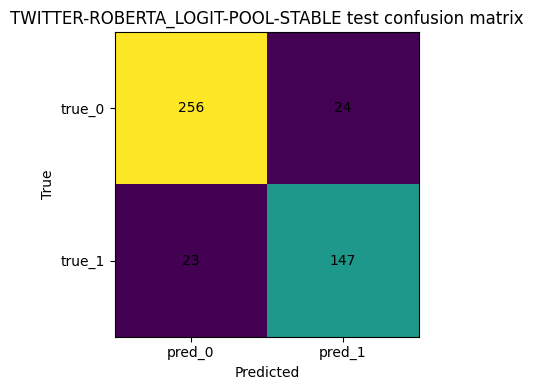

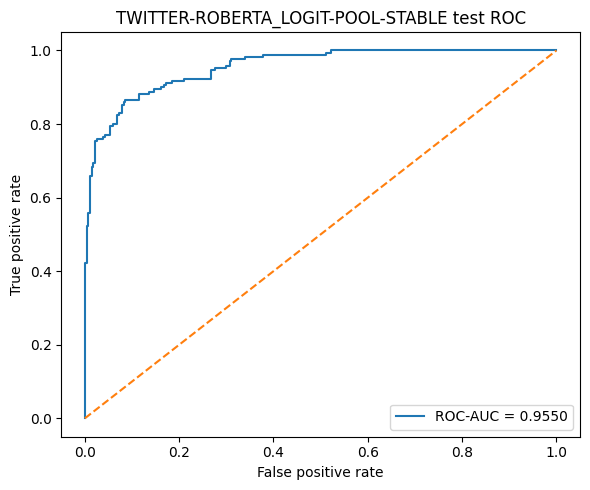

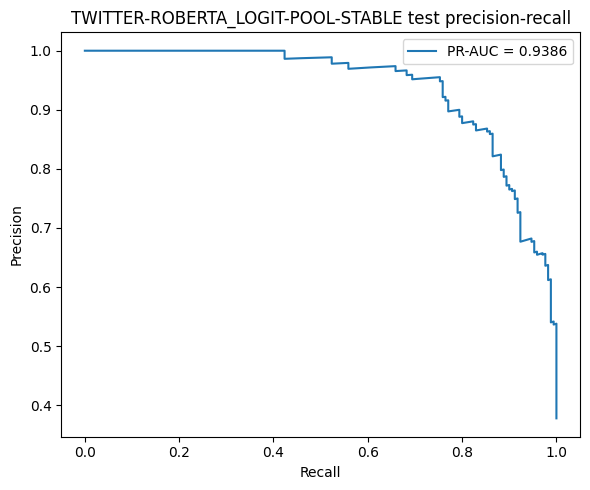

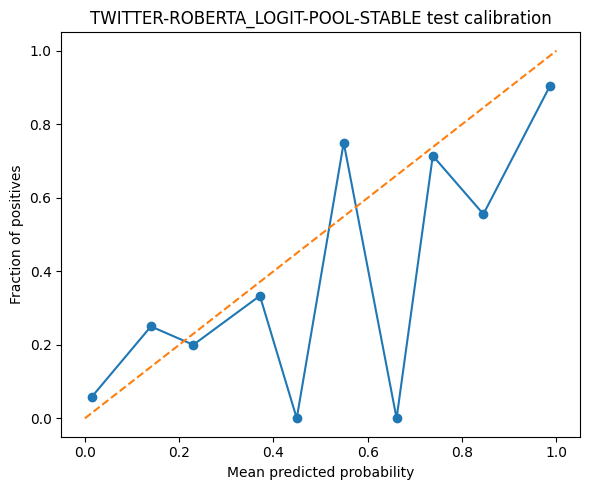

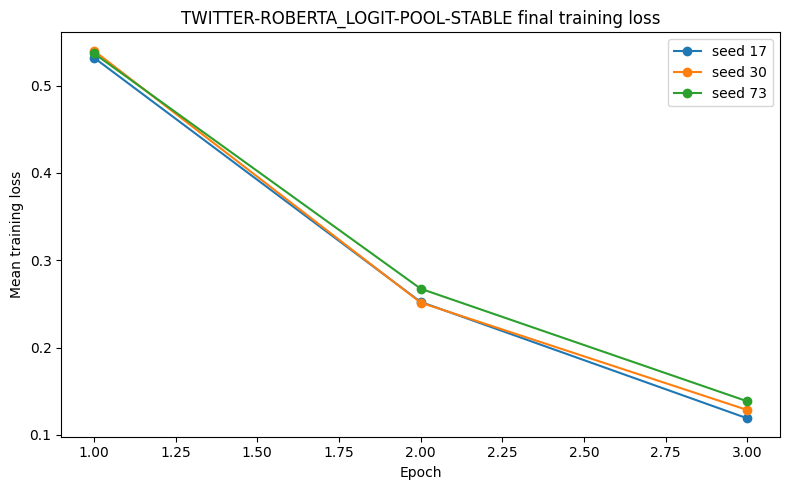

In [19]:
# ============================================================
# 19. Evaluation plots
# ============================================================

def save_confusion_matrix_plot(y_true, y_prob, threshold, path, title):
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["pred_0", "pred_1"])
    ax.set_yticklabels(["true_0", "true_1"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    fig.tight_layout(); fig.savefig(path, dpi=200, bbox_inches="tight"); plt.show()


def save_roc_plot(y_true, y_prob, path, title):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, label=f"ROC-AUC = {safe_roc_auc(y_true, y_prob):.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
    ax.set_title(title); ax.legend(); fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight"); plt.show()


def save_pr_plot(y_true, y_prob, path, title):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall, precision, label=f"PR-AUC = {safe_pr_auc(y_true, y_prob):.4f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(title); ax.legend(); fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight"); plt.show()


def save_calibration_plot(y_true, y_prob, path, title):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="uniform")
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(prob_pred, prob_true, marker="o")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Fraction of positives")
    ax.set_title(title); fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight"); plt.show()


save_confusion_matrix_plot(
    y_test, test_prob, selected_threshold,
    OUTPUT_DIR / "plots" / "confusion_matrix_test.png",
    f"{TECHNIQUE_NAME} test confusion matrix",
)
save_roc_plot(y_test, test_prob, OUTPUT_DIR / "plots" / "roc_curve_test.png", f"{TECHNIQUE_NAME} test ROC")
save_pr_plot(y_test, test_prob, OUTPUT_DIR / "plots" / "pr_curve_test.png", f"{TECHNIQUE_NAME} test precision-recall")
save_calibration_plot(y_test, test_prob, OUTPUT_DIR / "plots" / "calibration_curve_test.png", f"{TECHNIQUE_NAME} test calibration")

if not final_training_history.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    for seed, seed_history in final_training_history.groupby("random_seed"):
        ax.plot(seed_history["epoch"], seed_history["train_loss_mean"], marker="o", label=f"seed {seed}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Mean training loss")
    ax.set_title(f"{TECHNIQUE_NAME} final training loss"); ax.legend()
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "plots" / "final_training_loss.png", dpi=200, bbox_inches="tight")
    plt.show()

In [20]:
# ============================================================
# 20. Global interpretability: Gradient x Embedding
# ============================================================

# Explanations use the representative transformer seed. The final prediction can also include
# the character model, so attribution scores explain the transformer component, not the entire blend.
SPECIAL_TOKEN_SET = set(final_tokenizer.all_special_tokens)


def clean_token_for_display(token):
    return token.replace("Ġ", "").replace("▁", "")


def gradient_x_embedding_attribution(model, tokenizer, text, target_class=1, max_length=192):
    model.eval()
    encoded = tokenizer(
        str(text), truncation=True, max_length=int(max_length), return_tensors="pt"
    )
    input_ids = encoded["input_ids"].to(DEVICE)
    model_inputs = {
        key: value.to(DEVICE)
        for key, value in encoded.items()
        if key != "input_ids"
    }

    # Detach to create a leaf tensor whose gradient can be read reliably.
    embeddings = model.get_input_embeddings()(input_ids).detach()
    embeddings.requires_grad_(True)

    model.zero_grad(set_to_none=True)
    outputs = model(inputs_embeds=embeddings, **model_inputs)
    probabilities = torch.softmax(outputs.logits, dim=-1)[0]
    score = outputs.logits[0, int(target_class)]
    score.backward()

    attribution_values = (
        embeddings.grad * embeddings
    ).sum(dim=-1).squeeze(0).detach().cpu().numpy()
    token_ids = input_ids.squeeze(0).detach().cpu().numpy().tolist()
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    records = []
    for position, (token, token_id, attribution) in enumerate(
        zip(tokens, token_ids, attribution_values)
    ):
        if token in SPECIAL_TOKEN_SET:
            continue
        records.append({
            "token_position": position,
            "token": token,
            "token_display": clean_token_for_display(token),
            "token_id": int(token_id),
            "attribution_to_positive_logit": float(attribution),
            "abs_attribution_to_positive_logit": float(abs(attribution)),
            "representative_transformer_positive_probability": float(
                probabilities[1].detach().cpu()
            ),
            "representative_seed": int(representative_seed),
        })
    return records


attr_sample = test_predictions.copy()
attr_sample["priority"] = attr_sample["error_type"].isin(
    ["false_positive", "false_negative"]
).astype(int)
attr_sample["confidence_distance"] = np.abs(attr_sample["y_prob"] - selected_threshold)
attr_sample = attr_sample.sort_values(
    ["priority", "confidence_distance"], ascending=[False, False]
).head(CONFIG["explainability"]["max_global_attribution_examples"])

global_token_rows = []
for _, row in attr_sample.iterrows():
    try:
        records = gradient_x_embedding_attribution(
            final_model,
            final_tokenizer,
            row["model_input_text"],
            target_class=CONFIG["positive_label"],
            max_length=best_config["max_length"],
        )
        for record in records:
            record.update({
                "row_id": row["row_id"],
                "y_true": row["y_true"],
                "y_pred": row["y_pred"],
                "final_ensemble_probability": row["y_prob"],
                "error_type": row["error_type"],
            })
            global_token_rows.append(record)
    except RuntimeError as error:
        print(f"Attribution skipped for row_id={row['row_id']}: {error}")
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

global_token_attributions = pd.DataFrame(global_token_rows)
if not global_token_attributions.empty:
    global_summary = (
        global_token_attributions.groupby("token_display", as_index=False)
        .agg(
            mean_attribution_to_positive_logit=("attribution_to_positive_logit", "mean"),
            mean_abs_attribution_to_positive_logit=("abs_attribution_to_positive_logit", "mean"),
            occurrence_count=("token_display", "size"),
        )
        .sort_values("mean_attribution_to_positive_logit", ascending=False)
    )
    global_token_attributions.to_csv(
        OUTPUT_DIR / "interpretability" / "global_token_attributions_long.csv", index=False
    )
    global_summary.to_csv(
        OUTPUT_DIR / "interpretability" / "global_token_attribution_summary.csv", index=False
    )
    global_summary.head(CONFIG["explainability"]["top_n_global"]).to_csv(
        OUTPUT_DIR / "interpretability" / "top_positive_tokens_by_gradient.csv", index=False
    )
    global_summary.tail(CONFIG["explainability"]["top_n_global"]).sort_values(
        "mean_attribution_to_positive_logit", ascending=True
    ).to_csv(
        OUTPUT_DIR / "interpretability" / "top_negative_tokens_by_gradient.csv", index=False
    )
    display(global_summary.head(20))
else:
    global_summary = pd.DataFrame()
    print("No global attribution rows were produced.")

,token_display,mean_attribution_to_positive_logit,mean_abs_attribution_to_positive_logit,occurrence_count
169,ching,1.580485,1.580485,1
273,facing,0.952918,0.952918,1
544,ong,0.745226,0.757593,2
361,hopes,0.457108,0.457108,1
654,sects,0.422239,0.422239,1
139,brothers,0.408763,0.408763,1
608,race,0.383495,0.383495,1
381,igger,0.374767,0.374767,1
59,anti,0.340732,0.340732,1
215,destroys,0.323652,0.323652,1


In [21]:
# ============================================================
# 21. Local interpretability for selected test examples
# ============================================================

local_parts = []
n_local = CONFIG["explainability"]["local_examples_per_bucket"]
local_parts.append(
    test_predictions[test_predictions["error_type"] == "false_positive"]
    .sort_values("y_prob", ascending=False).head(n_local)
    .assign(explanation_bucket="highest_confidence_false_positive")
)
local_parts.append(
    test_predictions[test_predictions["error_type"] == "false_negative"]
    .sort_values("y_prob", ascending=True).head(n_local)
    .assign(explanation_bucket="highest_confidence_false_negative")
)
local_parts.append(
    test_predictions[(test_predictions["y_true"] == 1) & test_predictions["correct"]]
    .sort_values("y_prob", ascending=False).head(n_local)
    .assign(explanation_bucket="highest_confidence_true_positive")
)
local_parts.append(
    test_predictions[(test_predictions["y_true"] == 0) & test_predictions["correct"]]
    .sort_values("y_prob", ascending=True).head(n_local)
    .assign(explanation_bucket="highest_confidence_true_negative")
)

local_examples = pd.concat(local_parts, ignore_index=True).drop_duplicates("row_id")
local_records = []
local_long_rows = []

for _, row in local_examples.iterrows():
    try:
        token_records = gradient_x_embedding_attribution(
            final_model,
            final_tokenizer,
            row["model_input_text"],
            target_class=CONFIG["positive_label"],
            max_length=best_config["max_length"],
        )
        token_df = pd.DataFrame(token_records)
        if token_df.empty:
            top_positive, top_negative = [], []
        else:
            token_df["row_id"] = row["row_id"]
            token_df["explanation_bucket"] = row["explanation_bucket"]
            local_long_rows.append(token_df)
            top_positive = (
                token_df.sort_values("attribution_to_positive_logit", ascending=False)
                .head(CONFIG["explainability"]["top_n_local_tokens"])
                [["token_display", "attribution_to_positive_logit"]]
                .to_dict("records")
            )
            top_negative = (
                token_df.sort_values("attribution_to_positive_logit", ascending=True)
                .head(CONFIG["explainability"]["top_n_local_tokens"])
                [["token_display", "attribution_to_positive_logit"]]
                .to_dict("records")
            )

        local_records.append({
            "row_id": row["row_id"],
            "explanation_bucket": row["explanation_bucket"],
            "y_true": row["y_true"],
            "y_pred": row["y_pred"],
            "y_prob": row["y_prob"],
            "transformer_ensemble_prob": row["transformer_ensemble_prob"],
            "char_tfidf_prob": row["char_tfidf_prob"],
            "error_type": row["error_type"],
            "text_preview": row["text"][:CONFIG["explainability"]["max_text_chars_for_display"]],
            "top_positive_tokens_json": json.dumps(make_json_safe(top_positive)),
            "top_negative_tokens_json": json.dumps(make_json_safe(top_negative)),
        })
    except RuntimeError as error:
        print(f"Local attribution skipped for row_id={row['row_id']}: {error}")
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

local_explanations = pd.DataFrame(local_records)
local_explanations.to_csv(
    OUTPUT_DIR / "interpretability" / "local_token_attribution_explanations.csv", index=False
)
if local_long_rows:
    pd.concat(local_long_rows, ignore_index=True).to_csv(
        OUTPUT_DIR / "interpretability" / "local_token_attributions_long.csv", index=False
    )
display(local_explanations.head(20))

,row_id,explanation_bucket,y_true,y_pred,y_prob,transformer_ensemble_prob,char_tfidf_prob,error_type,text_preview,top_positive_tokens_json,top_negative_tokens_json
0,ex_001618,highest_confidence_false_positive,0,1,0.995713,0.995713,0.344489,false_positive,you are an evil despicable animal and i am sure eventually you will get yours god has a special plan for vile creatures like you,"[{""token_display"": ""despicable"", ""attribution_to_positive_logit"": 0.03921683132648468}, {""token_display"": ""animal"", ""attribution_to_posi...","[{""token_display"": ""god"", ""attribution_to_positive_logit"": -0.018208811059594154}, {""token_display"": ""like"", ""attribution_to_positive_lo..."
1,ex_001428,highest_confidence_false_positive,0,1,0.993078,0.993078,0.502921,false_positive,i am going to murder that fucking vagina,"[{""token_display"": ""fucking"", ""attribution_to_positive_logit"": 0.016750067472457886}, {""token_display"": ""am"", ""attribution_to_positive_l...","[{""token_display"": ""vagina"", ""attribution_to_positive_logit"": -0.047911666333675385}, {""token_display"": ""to"", ""attribution_to_positive_l..."
2,ex_000334,highest_confidence_false_positive,0,1,0.992224,0.992224,0.607203,false_positive,these animals have not been hunted for a long time so have lost their fear of men they will either need to be hunted down and dealt with...,"[{""token_display"": ""hunted"", ""attribution_to_positive_logit"": 0.1420479416847229}, {""token_display"": ""animals"", ""attribution_to_positive...","[{""token_display"": ""men"", ""attribution_to_positive_logit"": -0.16771717369556427}, {""token_display"": ""they"", ""attribution_to_positive_log..."
3,ex_000184,highest_confidence_false_positive,0,1,0.981689,0.981689,0.668092,false_positive,off your left wing high horse certainly not the average person s take on a refugee remove the country shoppers the opportunist migrants ...,"[{""token_display"": ""refugee"", ""attribution_to_positive_logit"": 0.15882965922355652}, {""token_display"": ""person"", ""attribution_to_positiv...","[{""token_display"": ""remove"", ""attribution_to_positive_logit"": -0.05382341891527176}, {""token_display"": ""high"", ""attribution_to_positive_..."
4,ex_002022,highest_confidence_false_positive,0,1,0.976669,0.976669,0.193047,false_positive,normal woman degenerates into a cunt,"[{""token_display"": ""ates"", ""attribution_to_positive_logit"": 0.018872395157814026}, {""token_display"": ""a"", ""attribution_to_positive_logit...","[{""token_display"": ""degener"", ""attribution_to_positive_logit"": -0.3385985195636749}, {""token_display"": ""woman"", ""attribution_to_positive..."
5,ex_001998,highest_confidence_false_positive,0,1,0.971202,0.971202,0.152865,false_positive,asked this bitch where she wants to eat she said porkies and i am done with white women man i do not care how fire the box is,"[{""token_display"": ""ask"", ""attribution_to_positive_logit"": 0.137019082903862}, {""token_display"": ""with"", ""attribution_to_positive_logit""...","[{""token_display"": ""women"", ""attribution_to_positive_logit"": -0.3248172998428345}, {""token_display"": ""white"", ""attribution_to_positive_l..."
6,ex_001873,highest_confidence_false_positive,0,1,0.941161,0.941161,0.342090,false_positive,sable is a whore and a cunt sunny destroys sable via,"[{""token_display"": ""able"", ""attribution_to_positive_logit"": 0.421098917722702}, {""token_display"": ""destroys"", ""attribution_to_positive_l...","[{""token_display"": ""able"", ""attribution_to_positive_logit"": -0.33751335740089417}, {""token_display"": ""sunny"", ""attribution_to_positive_l..."
7,ex_000523,highest_confidence_false_positive,0,1,0.936981,0.936981,0.528110,false_positive,if you claim you do not have the power to forgive but only allah why then do you arrogate yourself the power to avenge are you not doubl...,"[{""token_display"": ""sects"", ""attribution_to_positive_logit"": 0.42223888635635376}, {""token_display"": ""like"", ""attribution_to_positive_lo...

In [22]:
# ============================================================
# 22. Comparable, deduplicated error-analysis outputs
# ============================================================

error_df = test_predictions.copy()
error_df["abs_distance_to_threshold"] = np.abs(
    error_df["y_prob"] - error_df["threshold"]
)


def confidence_bucket(row):
    if row["abs_distance_to_threshold"] <= CONFIG["error_analysis"]["near_threshold_margin"]:
        return "near_threshold"
    if (
        row["y_prob"] >= CONFIG["error_analysis"]["high_confidence_positive"]
        or row["y_prob"] <= CONFIG["error_analysis"]["high_confidence_negative"]
    ):
        return "high_confidence"
    return "moderate_confidence"


error_df["confidence_bucket"] = error_df.apply(confidence_bucket, axis=1)
error_df["manual_error_category"] = ""
error_df["manual_notes"] = ""

if not local_explanations.empty:
    explanation_cols = local_explanations[
        ["row_id", "top_positive_tokens_json", "top_negative_tokens_json"]
    ].drop_duplicates("row_id")
    error_df = error_df.merge(explanation_cols, on="row_id", how="left")
else:
    error_df["top_positive_tokens_json"] = np.nan
    error_df["top_negative_tokens_json"] = np.nan

if CONFIG["error_analysis"]["include_text_preview"]:
    error_df["text_preview"] = error_df["text"].str.slice(
        0, CONFIG["error_analysis"]["text_preview_chars"]
    )

# Keep the legacy columns first so downstream comparison scripts continue to work.
legacy_error_columns = [
    "row_id", "text", "y_true", "split", "y_prob", "threshold", "y_pred",
    "correct", "error_type", "text_hash", "abs_distance_to_threshold",
    "confidence_bucket", "manual_error_category", "manual_notes",
    "top_positive_tokens_json", "top_negative_tokens_json", "text_preview",
]
extra_error_columns = [
    column for column in error_df.columns if column not in legacy_error_columns
]
error_df = error_df[legacy_error_columns + extra_error_columns]
error_df.to_csv(
    OUTPUT_DIR / "error_analysis" / "error_analysis_test.csv", index=False
)

# Each error receives one exclusive bucket; no row can appear twice.
errors_only = error_df[error_df["error_type"] != "correct"].copy()
errors_only["review_bucket"] = (
    errors_only["confidence_bucket"] + "_" + errors_only["error_type"]
)
errors_only["review_priority"] = errors_only["confidence_bucket"].map({
    "high_confidence": 1,
    "near_threshold": 2,
    "moderate_confidence": 3,
}).fillna(4)
errors_only["error_confidence_score"] = np.where(
    errors_only["error_type"] == "false_positive",
    errors_only["y_prob"],
    1.0 - errors_only["y_prob"],
)

n_review = CONFIG["error_analysis"]["examples_per_bucket"]
review_df = (
    errors_only.sort_values(
        ["review_priority", "error_confidence_score", "abs_distance_to_threshold"],
        ascending=[True, False, False],
    )
    .groupby("review_bucket", group_keys=False)
    .head(n_review)
    .drop_duplicates("row_id")
    .reset_index(drop=True)
)
review_df.to_csv(
    OUTPUT_DIR / "error_analysis" / "manual_review_queue_test.csv", index=False
)

# Preserve the exact three-column summary contract.
error_summary = (
    error_df.groupby(["error_type", "confidence_bucket"])
    .size().reset_index(name="count")
    .sort_values(["error_type", "confidence_bucket"])
)
error_summary.to_csv(
    OUTPUT_DIR / "error_analysis" / "error_summary.csv", index=False
)

manual_category_guide = pd.DataFrame({
    "manual_error_category": [
        "generic_toxicity", "quoted_or_reported_content", "counterspeech",
        "literal_nonhuman_violence", "implicit_extremism", "preprocessing_corruption",
        "ambiguous_label", "likely_label_error", "other",
    ],
    "definition": [
        "Abusive/profane content without the dataset's intended extremist signal.",
        "Extremist content is quoted, described, or reported rather than endorsed.",
        "The author rejects, challenges, or condemns extremist/hateful content.",
        "Violent words refer literally to animals, games, fiction, or another non-target context.",
        "Positive example uses coded, ideological, or contextual cues with little overt toxicity.",
        "Upstream normalization appears to have changed or damaged the wording.",
        "Reasonable annotators could disagree under the present ontology.",
        "The supplied gold label is probably incorrect after adjudication.",
        "Does not fit another category.",
    ],
})
manual_category_guide.to_csv(
    OUTPUT_DIR / "error_analysis" / "manual_error_category_guide.csv", index=False
)

print("Manual-review rows:", len(review_df))
print("Unique manual-review row_ids:", review_df["row_id"].nunique())
display(error_summary)
display(review_df.head(20))

Manual-review rows: 47
Unique manual-review row_ids: 47


,error_type,confidence_bucket,count
0,correct,high_confidence,355
1,correct,moderate_confidence,42
2,correct,near_threshold,6
3,false_negative,high_confidence,14
4,false_negative,moderate_confidence,9
5,false_positive,high_confidence,14
6,false_positive,moderate_confidence,9
7,false_positive,near_threshold,1


,row_id,text,y_true,split,y_prob,threshold,y_pred,correct,error_type,text_hash,abs_distance_to_threshold,confidence_bucket,manual_error_category,manual_notes,top_positive_tokens_json,top_negative_tokens_json,text_preview,model_input_text,transformer_ensemble_prob,transformer_logit_mean_prob,transformer_arithmetic_mean_prob,char_tfidf_prob,transformer_seed_17_prob,calibrated_transformer_seed_17_prob,transformer_seed_30_prob,calibrated_transformer_seed_30_prob,transformer_seed_73_prob,calibrated_transformer_seed_73_prob,selected_transformer_strategy,selected_transformer_weight,selected_char_tfidf_weight,review_bucket,review_priority,error_confidence_score
0,ex_001618,you are an evil despicable animal and i am sure eventually you will get yours god has a special plan for vile creatures like you,0,test,0.995713,0.5,1,False,false_positive,d0c41a9aa6434c80,0.495713,high_confidence,,,"[{""token_display"": ""despicable"", ""attribution_to_positive_logit"": 0.03921683132648468}, {""token_display"": ""animal"", ""attribution_to_posi...","[{""token_display"": ""god"", ""attribution_to_positive_logit"": -0.018208811059594154}, {""token_display"": ""like"", ""attribution_to_positive_lo...",you are an evil despicable animal and i am sure eventually you will get yours god has a special plan for vile creatures like you,you are an evil despicable animal and i am sure eventually you will get yours god has a special plan for vile creatures like you,0.995713,0.995713,0.992281,0.344489,0.983085,0.983085,0.999144,0.999144,0.994615,0.994615,raw_logit_mean__fixed_0_50,1.0,0.0,high_confidence_false_positive,1,0.995713
1,ex_001428,i am going to murder that fucking vagina,0,test,0.993078,0.5,1,False,false_positive,05c512c6e5feee82,0.493078,high_confidence,,,"[{""token_display"": ""fucking"", ""attribution_to_positive_logit"": 0.016750067472457886}, {""token_display"": ""am"", ""attribution_to_positive_l...","[{""token_display"": ""vagina"", ""attribution_to_positive_logit"": -0.047911666333675385}, {""token_display"": ""to"", ""attribution_to_positive_l...",i am going to murder that fucking vagina,i am going to murder that fucking vagina,0.993078,0.993078,0.986871,0.502921,0.971779,0.971779,0.998849,0.998849,0.989986,0.989986,raw_logit_mean__fixed_0_50,1.0,0.0,high_confidence_false_positive,1,0.993078
2,ex_001822,i know you like to be called a fag so i will not stop using that fucking it means cool a k a,1,test,0.007308,0.5,0,False,false_negative,2cc1fdc51403d13e,0.492692,high_confidence,,,"[{""token_display"": ""ag"", ""attribution_to_positive_logit"": 0.0355621874332428}, {""token_display"": ""called"", ""attribution_to_positive_logi...","[{""token_display"": ""i"", ""attribution_to_positive_logit"": -0.036311037838459015}, {""token_display"": ""means"", ""attribution_to_positive_log...",i know you like to be called a fag so i will not stop using that fucking it means cool a k a,i know you like to be called a fag so i will not stop using that fucking it means cool a k a,0.007308,0.007308,0.011189,0.148600,0.015664,0.015664,0.001501,0.001501,0.016403,0.016403,raw_logit_mean__fixed_0_50,1.0,0.0,high_confidence_false_negative,1,0.992692
3,ex_001802,would you like to be called a retarded then stop acting like one,1,test,0.007716,0.5,0,False,false_negative,02a16c9d0540ba02,0.492284,high_confidence,,,"[{""token_display"": ""called"", ""attribution_to_positive_logit"": 0.028363928198814392}, {""token_display"": ""acting"", ""attribution_to_positiv...","[{""token_display"": ""a"", ""attribution_to_positive_logit"": -0.04211657866835594}, {""token_display"": ""retarded"", ""attribution_to_positive_l...",would you like to be called a retarded then stop acting like one,would you like to be called a retarded then stop acting like one,0.007716,0.007716,0.013842,0.017464,0.022286,0.022286,0.001116,0.001116,0.018125,0.018125,raw_logit_mean__fixed_0_50,1.0,0.0,high_confidence_false_negative,1,0.992284
4,ex_000334,these animals have not been hunted for a long time so 

In [23]:
# ============================================================
# 23. Experiment metadata and README
# ============================================================

try:
    import transformers
    transformers_version = transformers.__version__
except Exception:
    transformers_version = None

metadata = {
    "run_id": RUN_ID,
    "technique": TECHNIQUE_NAME,
    "created_at_utc": dt.datetime.utcnow().replace(microsecond=0).isoformat() + "Z",
    "project_name": CONFIG["project_name"],
    "dataset_version": CONFIG["dataset_version"],
    "split_version": CONFIG["split_version"],
    "search_seed": CONFIG["random_seed"],
    "final_seeds": CONFIG["final_seeds"],
    "processed_dataset_path": str(processed_dataset_path),
    "processed_dataset_sha256_16": sha256_file(processed_dataset_path),
    "split_assignments_path": str(split_assignments_path),
    "split_assignments_sha256_16": sha256_file(split_assignments_path),
    "raw_dataset_path": str(raw_dataset_path) if raw_dataset_path is not None else None,
    "dataset_manifest": dataset_manifest,
    "text_input": text_source_audit,
    "software_environment": {
        "python_version": platform.python_version(),
        "platform": platform.platform(),
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
        "torch_version": torch.__version__,
        "transformers_version": transformers_version,
        "cuda_available": torch.cuda.is_available(),
    },
    "model_selection": {
        "ablation_split": "validation",
        "transformer_primary_metric": CONFIG["threshold_selection"]["metric"],
        "best_epoch_metric": CONFIG["transformer_training"]["metric_for_best_epoch"],
        "ensemble_weight_selected_on": "validation",
        "threshold_selected_on": "validation",
        "test_set_used_for_selection": False,
        "best_transformer_config": best_config,
        "representative_transformer_seed": representative_seed,
        "selected_transformer_strategy": selected_transformer_strategy,
        "seed_calibration": "disabled_raw_probabilities",
        "seed_pooling": "mean_log_odds_with_fixed_0_50_primary",
        "classifier_head_policy": checkpoint_head_policy(best_config["checkpoint"]),
    },
    "final_model": {
        "transformer_seeds": CONFIG["final_seeds"],
        "transformer_strategy": selected_transformer_strategy,
        "transformer_weight": selected_transformer_weight,
        "char_tfidf_weight": selected_char_weight,
        "blend_method": CONFIG["ensemble"]["blend_method"],
        "selected_threshold": selected_threshold,
    },
    "final_evaluation": {
        "validation_metrics": validation_metrics,
        "test_metrics": test_metrics,
        "important_limitation": (
            "Prior test errors informed this redesign. Use a fresh untouched holdout or nested cross-validation "
            "for a final unbiased performance claim."
        ),
    },
    "xai_method": {
        "global": "Gradient x Embedding token attribution over a capped test sample",
        "local": "Gradient x Embedding for selected test examples",
        "scope": "Representative transformer seed only; not a complete explanation of the blended ensemble.",
    },
    "outputs": {
        "config": "config.json",
        "best_config": "best_config.json",
        "ensemble_config": "ensemble_config.json",
        "ablation_results": "ablation/ablation_results.csv",
        "metrics_validation": "metrics_validation.json",
        "metrics_test": "metrics_test.json",
        "predictions_validation": "predictions_validation.csv",
        "predictions_test": "predictions_test.csv",
        "model_artifacts": "model_artifacts/",
        "plots": "plots/",
        "interpretability": "interpretability/",
        "error_analysis": "error_analysis/",
        "training_logs": "training_logs/",
        "data_quality": "data_quality/",
    },
}
save_json(metadata, OUTPUT_DIR / "metadata.json")

readme_text = f"""# {TECHNIQUE_NAME} outputs

This folder contains standardized outputs for the `{TECHNIQUE_NAME}` experiment.

## Why this revision exists

The prior raw-probability revision still used arithmetic seed averaging and a coarse 0.005 threshold grid. This revision uses mean log-odds pooling as the protected multi-seed operating point and evaluates exact validation decision intervals for all challenger thresholds.

## Modeling changes

- Restores the hate-speech-aligned Twitter RoBERTa checkpoint.
- Preserves its pretrained classifier head.
- Selects epochs using optimized validation accuracy.
- Uses raw transformer probabilities consistently for validation and test inference.
- Pools the three seed outputs by averaging log-odds rather than probabilities.
- Uses a prespecified 0.50 cutoff for the protected logit-pooled operating point.
- Evaluates arithmetic mean, exact validation-tuned logit mean, and individual seeds as challengers.
- Requires a challenger to beat the protected operating point by at least three validation examples.
- Evaluates exact probability-change intervals rather than relying only on a 0.005 threshold grid.
- Restores the original balanced-class-weight ablation.
- Keeps character TF-IDF for diagnostics only; it cannot alter the final prediction.
- Selects the exact validation-optimal threshold on the same raw probability scale used at test time.
- Keeps the deduplicated manual-review queue and standardized error-analysis files.

## Final configuration

- Transformer checkpoint: `{best_config['checkpoint']}`
- Classifier-head policy: `{checkpoint_head_policy(best_config['checkpoint'])}`
- Seeds: `{CONFIG['final_seeds']}`
- Transformer strategy: `{selected_transformer_strategy}`
- Transformer weight: `{selected_transformer_weight:.2f}`
- Character TF-IDF weight: `{selected_char_weight:.2f}`
- Threshold: `{selected_threshold:.3f}`
- Representative XAI/model-artifact seed: `{representative_seed}`

## Comparable core outputs

- `metrics_validation.json`
- `metrics_test.json`
- `predictions_validation.csv`
- `predictions_test.csv`
- `error_analysis/error_analysis_test.csv`
- `error_analysis/error_summary.csv`
- `error_analysis/manual_review_queue_test.csv`
- `ablation/ablation_results.csv`
- `training_logs/final_training_history.csv`

Legacy columns remain first. Additional columns expose raw and calibrated seed probabilities, the selected transformer strategy, component probabilities, and guarded ensemble weights.

## Important evaluation note

The previous test-set errors informed this redesign. Confirm the winning setup on a fresh untouched holdout or with nested cross-validation before making a final unbiased performance claim.

## Explainability note

Gradient x Embedding explains the representative transformer component. It is an approximate post-hoc attribution rather than a complete causal explanation of the final blended prediction.
"""
with open(OUTPUT_DIR / "README.md", "w", encoding="utf-8") as f:
    f.write(readme_text)

print("Saved metadata and README to:", OUTPUT_DIR)

Saved metadata and README to: /kaggle/working/experiments/TWITTER-ROBERTA_LOGIT-POOL-STABLE


In [24]:
# ============================================================
# 24. Zip outputs for download / Google Drive storage
# ============================================================

zip_base = Path("/kaggle/working") / f"{TECHNIQUE_NAME}_outputs"
zip_path = shutil.make_archive(
    base_name=str(zip_base),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("Created zip file:")
print(zip_path)
print("\nSuggested Google Drive destination:")
print(f"Extremism-Classification-Research/01_model_outputs/{TECHNIQUE_NAME}/")

Created zip file:
/kaggle/working/TWITTER-ROBERTA_LOGIT-POOL-STABLE_outputs.zip

Suggested Google Drive destination:
Extremism-Classification-Research/01_model_outputs/TWITTER-ROBERTA_LOGIT-POOL-STABLE/
